# Electricity Usage Forecasting: Clustering & Per-Cluster Models

**Dataset:** 370 metering points (MT_001–MT_370), 15-min intervals, 2011–2014.  
**Goal:** Cluster clients by usage pattern, then build tailored time series models per cluster.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Data Loading & Preprocessing

In [ ]:
# Load raw 15-min data
df_raw = pd.read_csv(
    "electricity.txt",
    sep=";",
    decimal=",",
    index_col=0,
    parse_dates=True,
)
print(f"Raw shape: {df_raw.shape}")  # expected ~140,256 rows × 370 cols
df_raw.head()

Raw shape: (140256, 370)


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Resample 15-min → hourly (mean of four 15-min blocks = avg kWh)
df_hourly = df_raw.resample("h").mean()

# Drop sparse 2011 startup period; keep 2012-01-01 to 2015-01-01
df_hourly = df_hourly.loc["2012-01-01":"2014-12-31"]

print(f"Hourly shape: {df_hourly.shape}")  # expected ~26,304 rows × 370 cols
print(f"Date range:   {df_hourly.index[0]}  →  {df_hourly.index[-1]}")
df_hourly.head()

Hourly shape: (26304, 370)
Date range:   2012-01-01 00:00:00  →  2014-12-31 23:00:00


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2012-01-01 00:00:00,3.172589,17.069701,57.993050,103.150407,53.353659,263.392857,6.783493,209.595960,55.944056,65.860215,...,92.612420,20025.0,1179.324895,1250.000000,11.734029,9.215916,389.157155,45.075125,540.139296,0.0
2012-01-01 01:00:00,4.124365,22.581792,77.324066,138.211382,72.256098,340.029762,6.783493,275.252525,67.307692,84.408602,...,112.598144,23800.0,1160.337553,1653.409091,15.971317,11.263897,543.898156,62.604341,708.211144,0.0
2012-01-01 02:00:00,4.758883,23.470839,77.324066,139.227642,67.378049,309.523810,6.924816,255.892256,66.870629,74.462366,...,107.066381,24150.0,1070.675105,1642.045455,15.645372,10.239906,547.848990,53.839733,690.249267,0.0
2012-01-01 03:00:00,4.441624,22.226174,77.324066,110.264228,52.743902,210.565476,5.652911,207.912458,44.143357,52.150538,...,72.626695,23625.0,1054.852321,1590.909091,15.971317,9.215916,328.358209,47.996661,683.284457,0.0
2012-01-01 04:00:00,4.758883,21.870555,77.324066,85.873984,47.256098,161.458333,3.533070,182.659933,46.328671,44.086022,...,69.236260,22825.0,1028.481013,1573.863636,18.252934,9.508484,343.942054,47.161937,679.985337,0.0


In [ ]:
# Check for missing values
missing = df_hourly.isnull().sum()
print(f"Clients with any missing hours: {(missing > 0).sum()} / {df_hourly.shape[1]}")
print(f"Max missing hours in a single client: {missing.max()}")

# Forward-fill short gaps (≤ 3 hrs), then drop remaining NaNs
df_hourly = df_hourly.ffill(limit=3).dropna(axis=1)
print(f"Clients retained after cleaning: {df_hourly.shape[1]}")

Clients with any missing hours: 0 / 370
Max missing hours in a single client: 0
Clients retained after cleaning: 370


## 2. Exploratory Data Analysis

The central EDA question: **how diverse are these 370 clients, and along what dimensions?**  
That diversity motivates clustering — a single model for all clients is likely suboptimal.

### 2a. Diversity Visualization — Sampled Clients

Plot 12 randomly sampled clients over a 2-week window to visually establish that usage patterns differ substantially across clients.

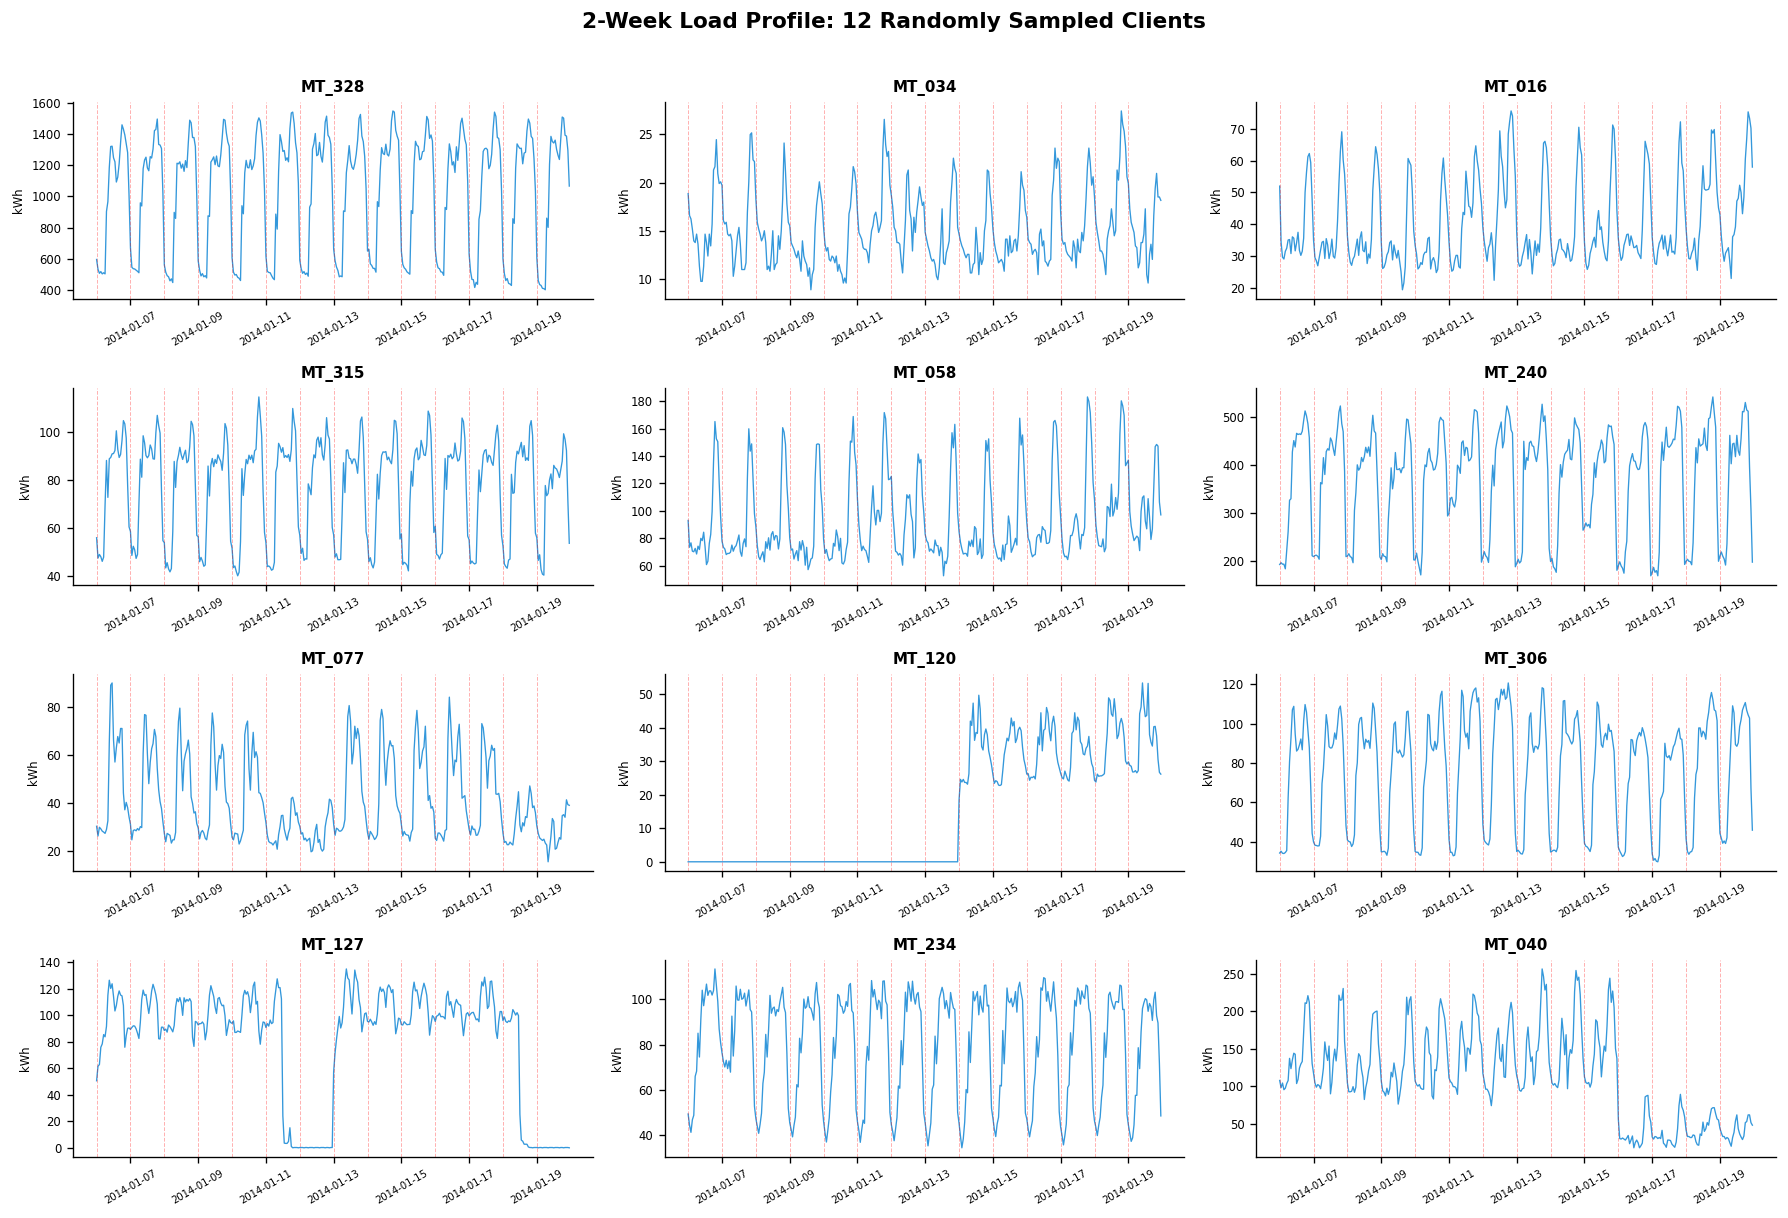

In [ ]:
np.random.seed(42)
sample_clients = np.random.choice(df_hourly.columns, size=12, replace=False)

# 2-week window from a representative period
window = df_hourly.loc["2014-01-06":"2014-01-19", sample_clients]

fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharey=False)
axes = axes.flatten()

for i, client in enumerate(sample_clients):
    axes[i].plot(window.index, window[client], color="#3498db", linewidth=0.8)
    axes[i].set_title(client, fontsize=9, fontweight="bold")
    axes[i].set_ylabel("kWh", fontsize=7)
    axes[i].tick_params(axis="x", labelsize=6, rotation=30)
    axes[i].tick_params(axis="y", labelsize=7)
    # Mark day boundaries
    for day in pd.date_range(window.index[0], window.index[-1], freq="D"):
        axes[i].axvline(day, color="red", alpha=0.3, linewidth=0.6, linestyle="--")

fig.suptitle("2-Week Load Profile: 12 Randomly Sampled Clients", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

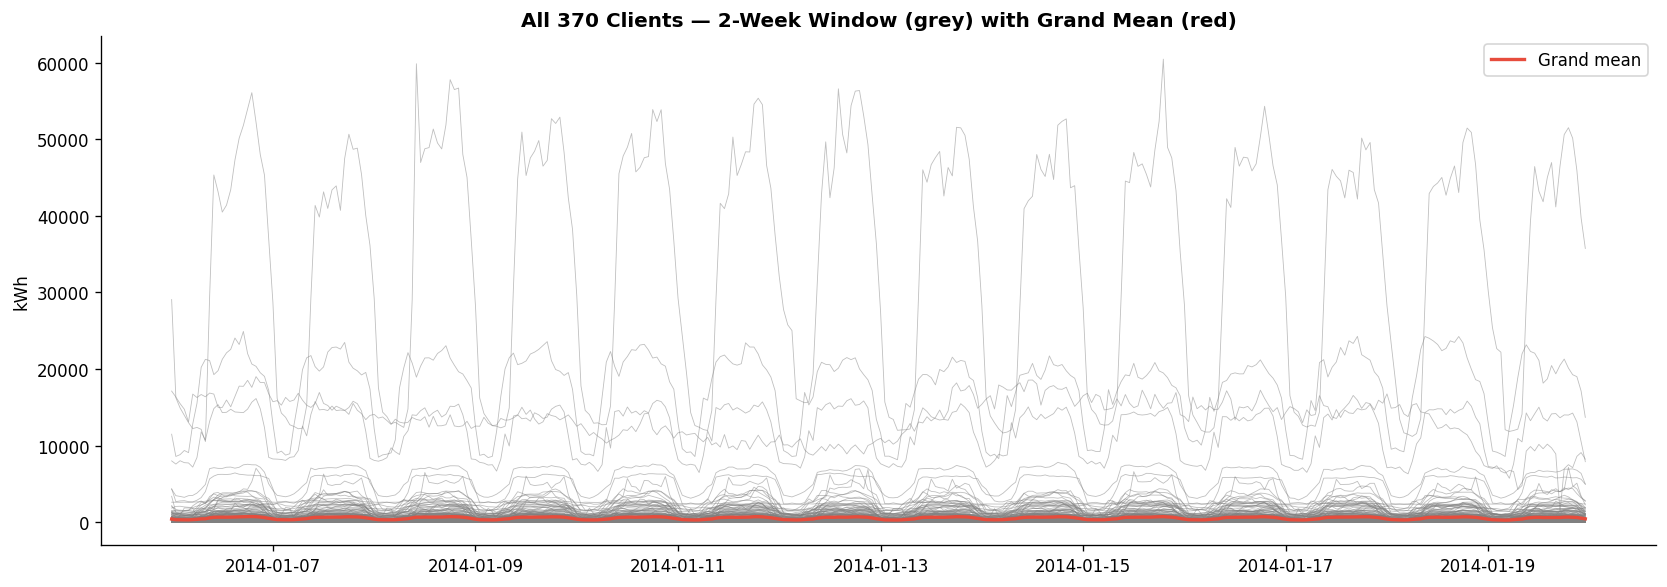

In [ ]:
# All clients overlaid — faint grey, grand mean on top
window_all = df_hourly.loc["2014-01-06":"2014-01-19"]

fig, ax = plt.subplots(figsize=(14, 5))
for col in window_all.columns:
    ax.plot(window_all.index, window_all[col], color="grey", alpha=0.5, linewidth=0.5)

grand_mean = window_all.mean(axis=1)
ax.plot(window_all.index, grand_mean, color="#e74c3c", linewidth=2, label="Grand mean")

ax.set_title("All 370 Clients — 2-Week Window (grey) with Grand Mean (red)", fontsize=12, fontweight="bold")
ax.set_ylabel("kWh")
ax.legend()
plt.tight_layout()
plt.show()

### 2b. Heatmap: Client × Hour-of-Day

Average consumption per hour-of-day for each client. Rows that look similar visually are natural cluster candidates.

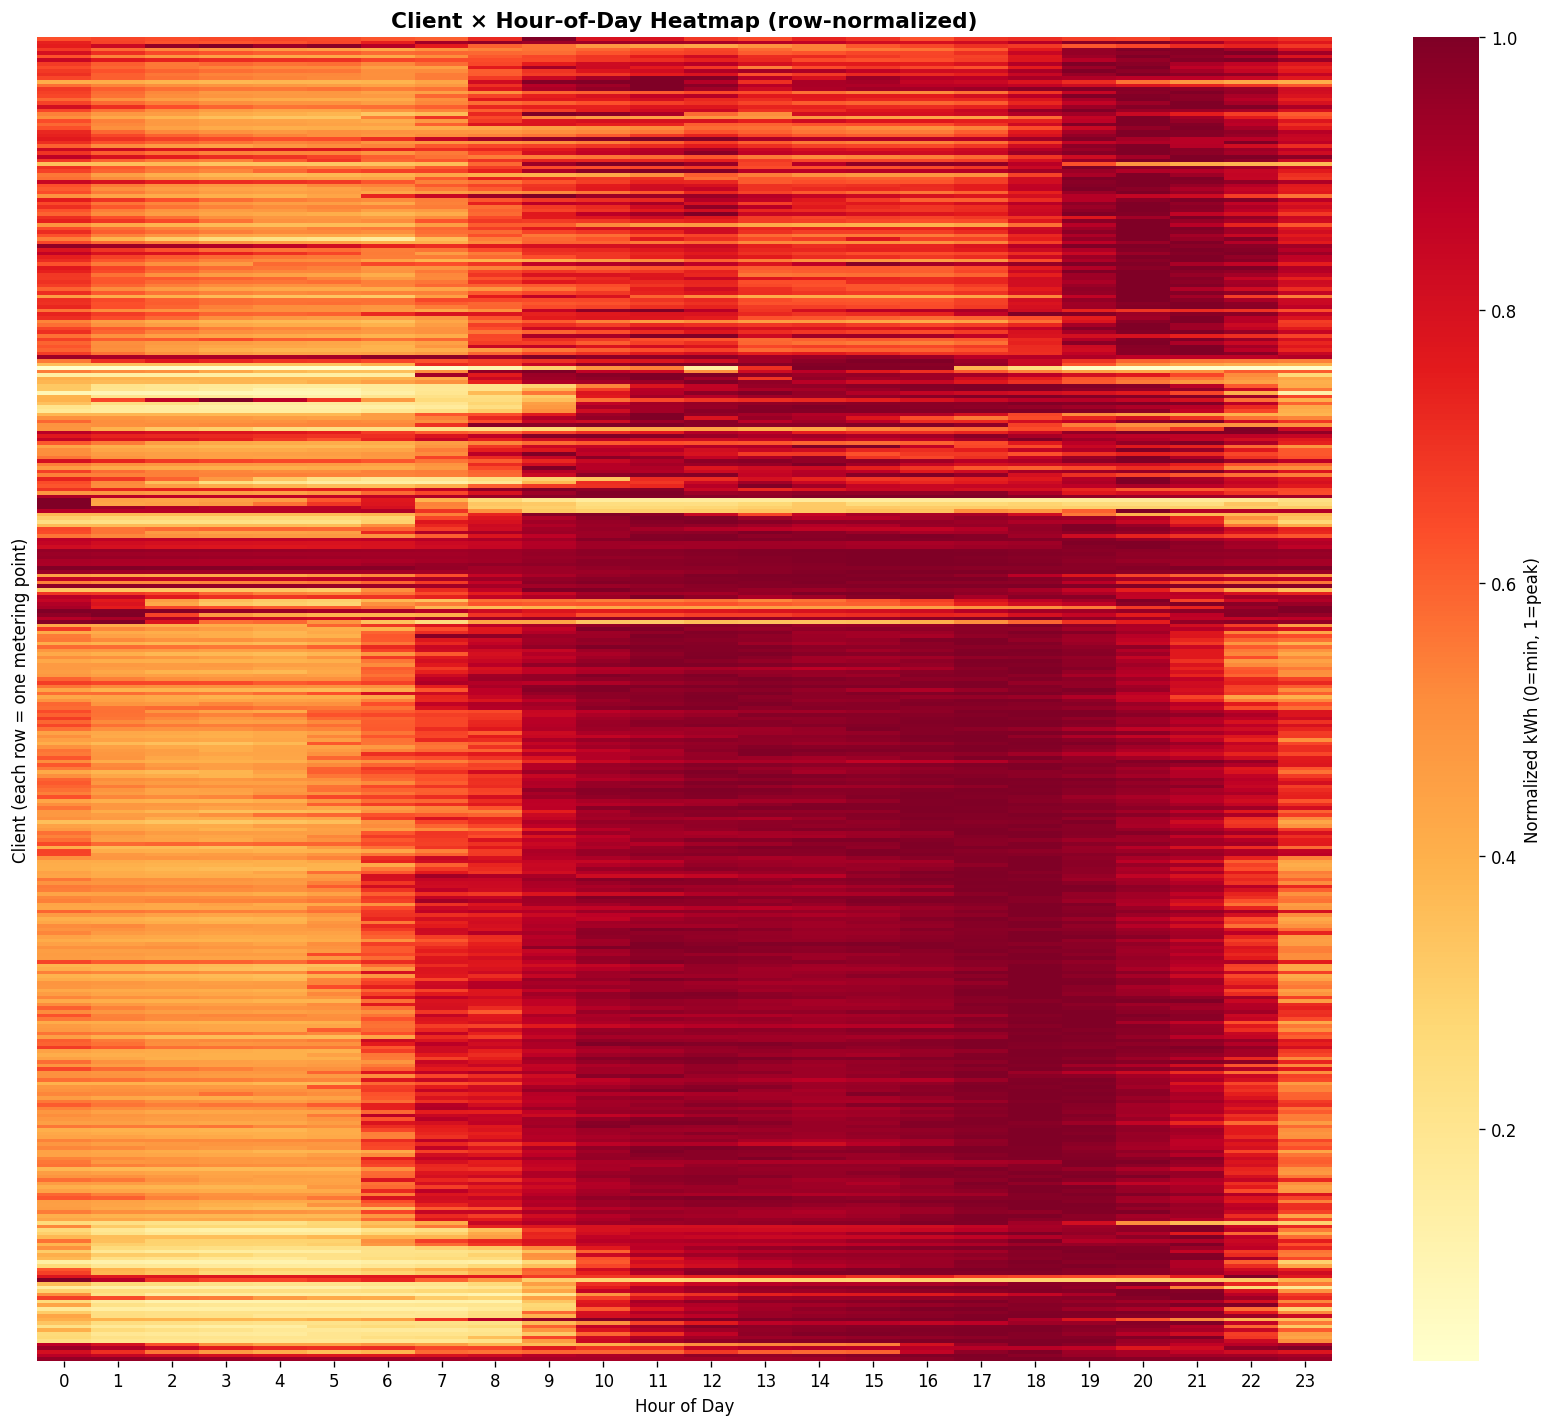

In [ ]:
# Build client × hour-of-day matrix (mean kWh per hour, averaged over all days)
df_hourly_copy = df_hourly.copy()
df_hourly_copy["hour"] = df_hourly_copy.index.hour

# shape: (370, 24) — each row is one client, each col is an hour 0–23
hourly_profile = (
    df_hourly_copy.groupby("hour")
    .mean()
    .T  # transpose: clients as rows, hours as columns
)
hourly_profile.index.name = "client"
hourly_profile.columns.name = "hour_of_day"

# Normalize each client to [0, 1] so shape (not magnitude) drives the heatmap
hourly_norm = hourly_profile.div(hourly_profile.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    hourly_norm,
    ax=ax,
    cmap="YlOrRd",
    xticklabels=list(range(24)),
    yticklabels=False,   # 370 rows — too many to label individually
    cbar_kws={"label": "Normalized kWh (0=min, 1=peak)"},
)
ax.set_title("Client × Hour-of-Day Heatmap (row-normalized)", fontsize=13, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Client (each row = one metering point)")
plt.tight_layout()
plt.show()

### 2c. Weekday vs. Weekend Scatter

Residential and commercial clients tend to flip: residential peaks on weekends, commercial peaks on weekdays. This scatter reveals that split clearly.

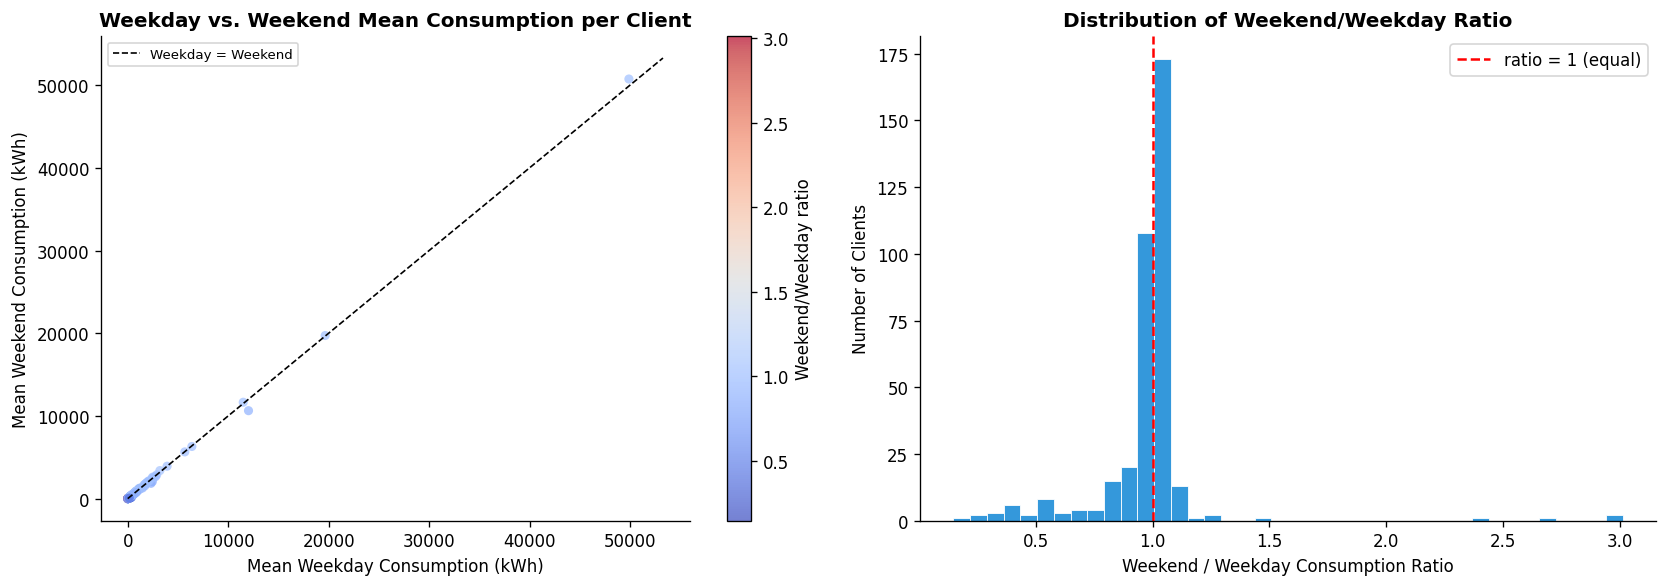

Clients with higher weekend consumption (ratio > 1): 232
Clients with higher weekday consumption (ratio < 1): 138


In [ ]:
df_wd = df_hourly.copy()
df_wd["dayofweek"] = df_wd.index.dayofweek  # 0=Mon … 6=Sun

weekday_mean = df_wd[df_wd["dayofweek"] < 5].drop(columns="dayofweek").mean()
weekend_mean = df_wd[df_wd["dayofweek"] >= 5].drop(columns="dayofweek").mean()

# Ratio: weekend / weekday  (>1 → residential-leaning, <1 → commercial-leaning)
ratio = weekend_mean / weekday_mean

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter
sc = axes[0].scatter(
    weekday_mean, weekend_mean,
    c=ratio, cmap="coolwarm", alpha=0.7, edgecolors="none", s=30
)
lim_max = max(weekday_mean.max(), weekend_mean.max()) * 1.05
axes[0].plot([0, lim_max], [0, lim_max], "k--", linewidth=1, label="Weekday = Weekend")
axes[0].set_xlabel("Mean Weekday Consumption (kWh)")
axes[0].set_ylabel("Mean Weekend Consumption (kWh)")
axes[0].set_title("Weekday vs. Weekend Mean Consumption per Client", fontweight="bold")
axes[0].legend(fontsize=8)
plt.colorbar(sc, ax=axes[0], label="Weekend/Weekday ratio")

# Right: histogram of the ratio
axes[1].hist(ratio, bins=40, color="#3498db", edgecolor="white", linewidth=0.5)
axes[1].axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="ratio = 1 (equal)")
axes[1].set_xlabel("Weekend / Weekday Consumption Ratio")
axes[1].set_ylabel("Number of Clients")
axes[1].set_title("Distribution of Weekend/Weekday Ratio", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Clients with higher weekend consumption (ratio > 1): {(ratio > 1).sum()}")
print(f"Clients with higher weekday consumption (ratio < 1): {(ratio < 1).sum()}")

### 2d. Summary Statistics Distributions

Per-client statistics that capture consumption level, variability, peakiness, and temporal autocorrelation. These will double as features for clustering.

In [ ]:
from statsmodels.tsa.stattools import acf

stats = pd.DataFrame(index=df_hourly.columns)

stats["mean_kwh"]       = df_hourly.mean()
stats["std_kwh"]        = df_hourly.std()
stats["cv"]             = stats["std_kwh"] / stats["mean_kwh"]          # coefficient of variation
stats["peak_to_mean"]   = df_hourly.max() / df_hourly.mean()            # peakiness
stats["weekend_wd_ratio"] = ratio                                        # from 2c above

# Autocorrelation at lag 24 (daily seasonality) and lag 168 (weekly seasonality)
stats["acf_lag24"]  = [acf(df_hourly[c].dropna(), nlags=24,  fft=True)[-1]  for c in df_hourly.columns]
stats["acf_lag168"] = [acf(df_hourly[c].dropna(), nlags=168, fft=True)[-1]  for c in df_hourly.columns]

stats.describe().round(3)

,mean_kwh,std_kwh,cv,peak_to_mean,weekend_wd_ratio,acf_lag24,acf_lag168
count,370.000,370.000,370.000,370.000,370.000,370.000,370.000
mean,594.094,283.645,0.535,3.395,0.977,0.887,0.889
std,2968.764,1995.075,0.442,4.014,0.247,0.126,0.087
min,1.090,2.109,0.077,1.565,0.148,0.124,0.185
25%,53.796,25.509,0.296,1.990,0.969,0.870,0.865
50%,122.225,49.393,0.347,2.366,1.008,0.936,0.915
75%,308.189,118.083,0.586,3.038,1.024,0.956,0.938
max,50132.281,36513.653,3.155,40.423,3.012,0.993,0.980


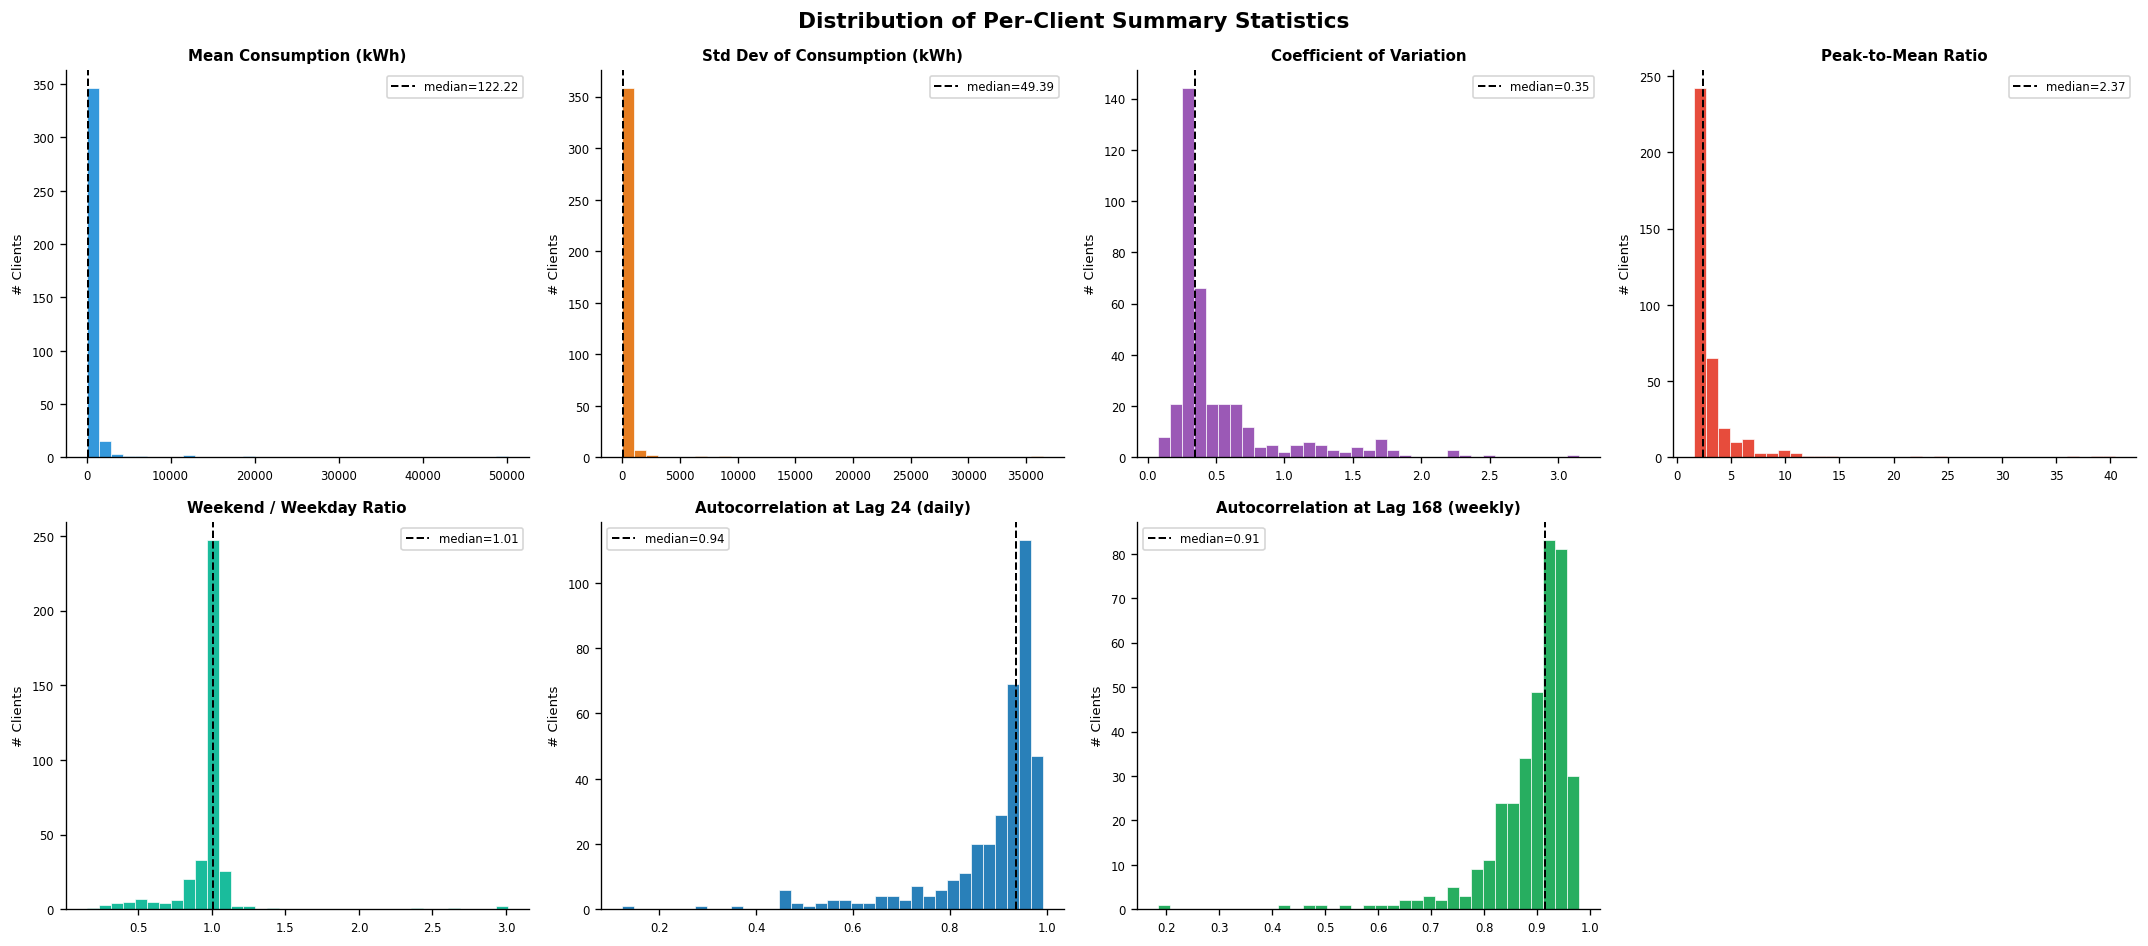

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

plot_config = [
    ("mean_kwh",         "Mean Consumption (kWh)",        "#3498db"),
    ("std_kwh",          "Std Dev of Consumption (kWh)",   "#e67e22"),
    ("cv",               "Coefficient of Variation",       "#9b59b6"),
    ("peak_to_mean",     "Peak-to-Mean Ratio",             "#e74c3c"),
    ("weekend_wd_ratio", "Weekend / Weekday Ratio",        "#1abc9c"),
    ("acf_lag24",        "Autocorrelation at Lag 24 (daily)",  "#2980b9"),
    ("acf_lag168",       "Autocorrelation at Lag 168 (weekly)", "#27ae60"),
]

for ax, (col, label, color) in zip(axes, plot_config):
    ax.hist(stats[col].dropna(), bins=35, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(stats[col].median(), color="black", linestyle="--", linewidth=1.2, label=f"median={stats[col].median():.2f}")
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_ylabel("# Clients", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

axes[-1].set_visible(False)  # hide unused 8th subplot
fig.suptitle("Distribution of Per-Client Summary Statistics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Feature Engineering for Clustering

Each client's raw series is ~26,000 points — too high-dimensional for K-Means.  
We compress each client into a small vector of interpretable features that capture:
- **Shape** of the typical daily cycle (normalized hourly profile)
- **Behavior type** (weekday vs. weekend, peakiness)
- **Seasonality strength** (how regular/predictable the client is)
- **Noise level** (residual variance after removing trend + seasonality)

The final feature matrix feeds directly into clustering in the next section.

In [ ]:
# --- Feature 1: Normalized 24-hour load profile (shape, not magnitude) ---
# Each client's average consumption per hour-of-day, divided by its own daily max.
# This makes a factory and a small shop with identical daily rhythms look the same,
# so clustering is driven by *when* they consume, not *how much*.

df_feat = df_hourly.copy()
df_feat["hour"] = df_feat.index.hour

# (370 clients) × (24 hours) — each value is average kWh at that hour
hourly_profile_raw = df_feat.groupby("hour").mean().T          # shape: 370 × 24

# Row-normalize: divide each client by its own peak hour value
hourly_profile_norm = hourly_profile_raw.div(hourly_profile_raw.max(axis=1), axis=0)
hourly_profile_norm.columns = [f"h{h:02d}" for h in range(24)]

print(f"Normalized hourly profile matrix: {hourly_profile_norm.shape}")
hourly_profile_norm.head(3)

Normalized hourly profile matrix: (370, 24)


,h00,h01,h02,h03,h04,h05,h06,h07,h08,h09,...,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23
MT_001,0.633453,0.657037,0.642307,0.649481,0.654175,0.651046,0.621356,0.603725,0.723134,1.000000,...,0.737216,0.700275,0.629522,0.700580,0.715730,0.675775,0.669020,0.726187,0.729889,0.706686
MT_002,0.740031,0.663908,0.629968,0.623327,0.630230,0.655958,0.744993,0.931222,0.963736,0.939298,...,0.863738,0.816143,0.801028,0.822279,0.888579,0.973961,1.000000,0.915685,0.810706,0.769698
MT_003,0.752474,0.835837,0.961771,1.000000,0.944081,0.976436,0.890866,0.754894,0.599523,0.560511,...,0.539368,0.618281,0.654232,0.706343,0.683847,0.618388,0.656759,0.718445,0.741048,0.692425


In [ ]:
from statsmodels.tsa.seasonal import STL

# --- Feature 2: STL decomposition features (seasonality strength & noise level) ---
# STL splits each series into trend + seasonal + residual.
# - seasonal_strength: how much variance the seasonal component explains (0=flat, 1=perfectly regular)
#   Formula: 1 - Var(residual) / Var(seasonal + residual)
#   High value → very regular daily cycle → SARIMA will fit well
# - residual_cv: std(residual) / mean(series) — relative noise after removing structure
#   High value → erratic client, harder to forecast

seasonal_strength = {}
residual_cv       = {}

for client in df_hourly.columns:
    series = df_hourly[client].dropna()
    # period=24: one full daily cycle in hourly data
    stl = STL(series, period=24, robust=True).fit()

    var_resid    = np.var(stl.resid)
    var_seas_res = np.var(stl.seasonal + stl.resid)

    seasonal_strength[client] = 1 - var_resid / var_seas_res if var_seas_res > 0 else 0
    residual_cv[client]       = np.std(stl.resid) / series.mean() if series.mean() > 0 else np.nan

stl_features = pd.DataFrame({
    "seasonal_strength": seasonal_strength,
    "residual_cv":       residual_cv,
})

print(stl_features.describe().round(3))

       seasonal_strength  residual_cv
count            370.000      370.000
mean               0.829        0.143
std                0.201        0.170
min               -0.010        0.000
25%                0.826        0.068
50%                0.920        0.088
75%                0.950        0.135
max                1.000        1.633


In [ ]:
# --- Feature 3: Scalar behavioral features (from EDA section) ---
# These summarize *how much* and *how erratically* each client consumes,
# and whether they skew residential (weekend-heavy) or commercial (weekday-heavy).
# peak_to_mean: spiky clients (e.g. batch industrial loads) vs. flat consumers
# acf_lag24/168: strength of daily/weekly periodicity — directly predicts SARIMA fit quality

scalar_features = stats[["mean_kwh", "cv", "peak_to_mean", "weekend_wd_ratio", "acf_lag24", "acf_lag168"]]

print(f"Scalar features: {scalar_features.shape}")
scalar_features.head(3)

Scalar features: (370, 6)


,mean_kwh,cv,peak_to_mean,weekend_wd_ratio,acf_lag24,acf_lag168
MT_001,5.293148,1.141895,6.533205,0.868473,0.753419,0.580166
MT_002,27.684801,0.231072,2.646126,1.024641,0.776857,0.738462
MT_003,3.890173,3.154933,38.469364,1.087751,0.625353,0.531783


In [ ]:
# --- Combine & standardize all features ---
# Concatenate the 24-dim profile shape + 2 STL features + 6 scalar features → 32-dim vector per client.
# StandardScaler is critical here: mean_kwh is in hundreds of kWh while acf values are in [0,1].
# Without scaling, K-Means distance is dominated by the largest-magnitude features.

feature_matrix = pd.concat([hourly_profile_norm, stl_features, scalar_features], axis=1)
feature_matrix = feature_matrix.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_matrix)
X_scaled = pd.DataFrame(X_scaled, index=feature_matrix.index, columns=feature_matrix.columns)

print(f"Final feature matrix: {X_scaled.shape}  ({X_scaled.shape[0]} clients × {X_scaled.shape[1]} features)")
X_scaled.head(3)

Final feature matrix: (370, 32)  (370 clients × 32 features)


,h00,h01,h02,h03,h04,h05,h06,h07,h08,h09,...,h22,h23,seasonal_strength,residual_cv,mean_kwh,cv,peak_to_mean,weekend_wd_ratio,acf_lag24,acf_lag168
MT_001,0.374481,0.815872,0.915149,1.059690,1.135852,1.011799,0.423971,-0.105393,0.223525,1.192563,...,-0.343948,0.291746,-3.009139,2.262089,-0.198601,1.376099,0.783068,-0.440460,-1.059948,-3.566784
MT_002,0.976977,0.855375,0.841686,0.902962,0.991319,1.041282,1.112587,1.532717,1.481380,0.863130,...,0.159855,0.650621,-0.931188,-0.165843,-0.191048,-0.689227,-0.186720,0.193658,-0.873778,-1.738530
MT_003,1.047320,1.843820,2.817197,3.160181,2.885718,2.964767,1.925052,0.650744,-0.422706,-1.192572,...,-0.274382,0.210526,0.260158,3.508143,-0.199074,5.940742,8.750822,0.449920,-2.077219,-4.125599


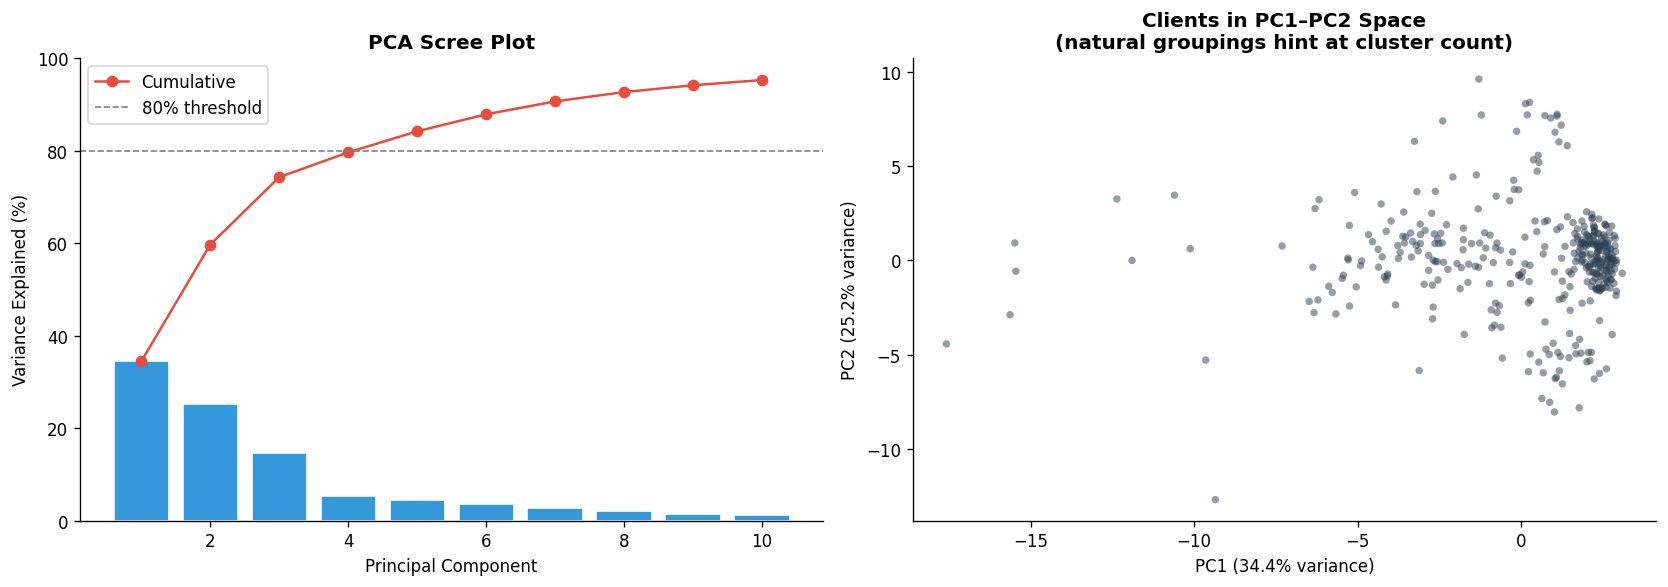

Variance explained by first 2 PCs: 59.7%
Variance explained by first 5 PCs: 84.2%


In [ ]:
from sklearn.decomposition import PCA

# --- PCA: reduce 32-dim feature space for visualization & optional clustering ---
# PCA finds the directions of maximum variance in the feature space.
# Plotting PC1 vs PC2 gives the best possible 2D view of client separation —
# if natural clusters exist, they'll be visible here before we run any clustering algorithm.
# FOR VISUALIZATION ONLY

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scree plot — how many components are worth keeping?
axes[0].bar(range(1, 11), explained * 100, color="#3498db", edgecolor="white")
axes[0].plot(range(1, 11), cumulative * 100, "o-", color="#e74c3c", linewidth=1.5, label="Cumulative")
axes[0].axhline(80, color="grey", linestyle="--", linewidth=1, label="80% threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("PCA Scree Plot", fontweight="bold")
axes[0].legend()

# Right: PC1 vs PC2 scatter — visual pre-check for cluster structure
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=20, color="#2c3e50", edgecolors="none")
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
axes[1].set_title("Clients in PC1–PC2 Space\n(natural groupings hint at cluster count)", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Variance explained by first 2 PCs: {cumulative[1]*100:.1f}%")
print(f"Variance explained by first 5 PCs: {cumulative[4]*100:.1f}%")

## 4. Clustering

**Strategy:**
1. **Hierarchical clustering** on all 32 scaled features → dendrogram reveals a natural `k`
2. **K-Means** on the 24-dim normalized hourly profiles using that `k` → interpretable, plottable centroids
3. **Validate** with silhouette scores + mean ± std load profile per cluster

### 4a. Hierarchical Clustering — Discover k from the Dendrogram

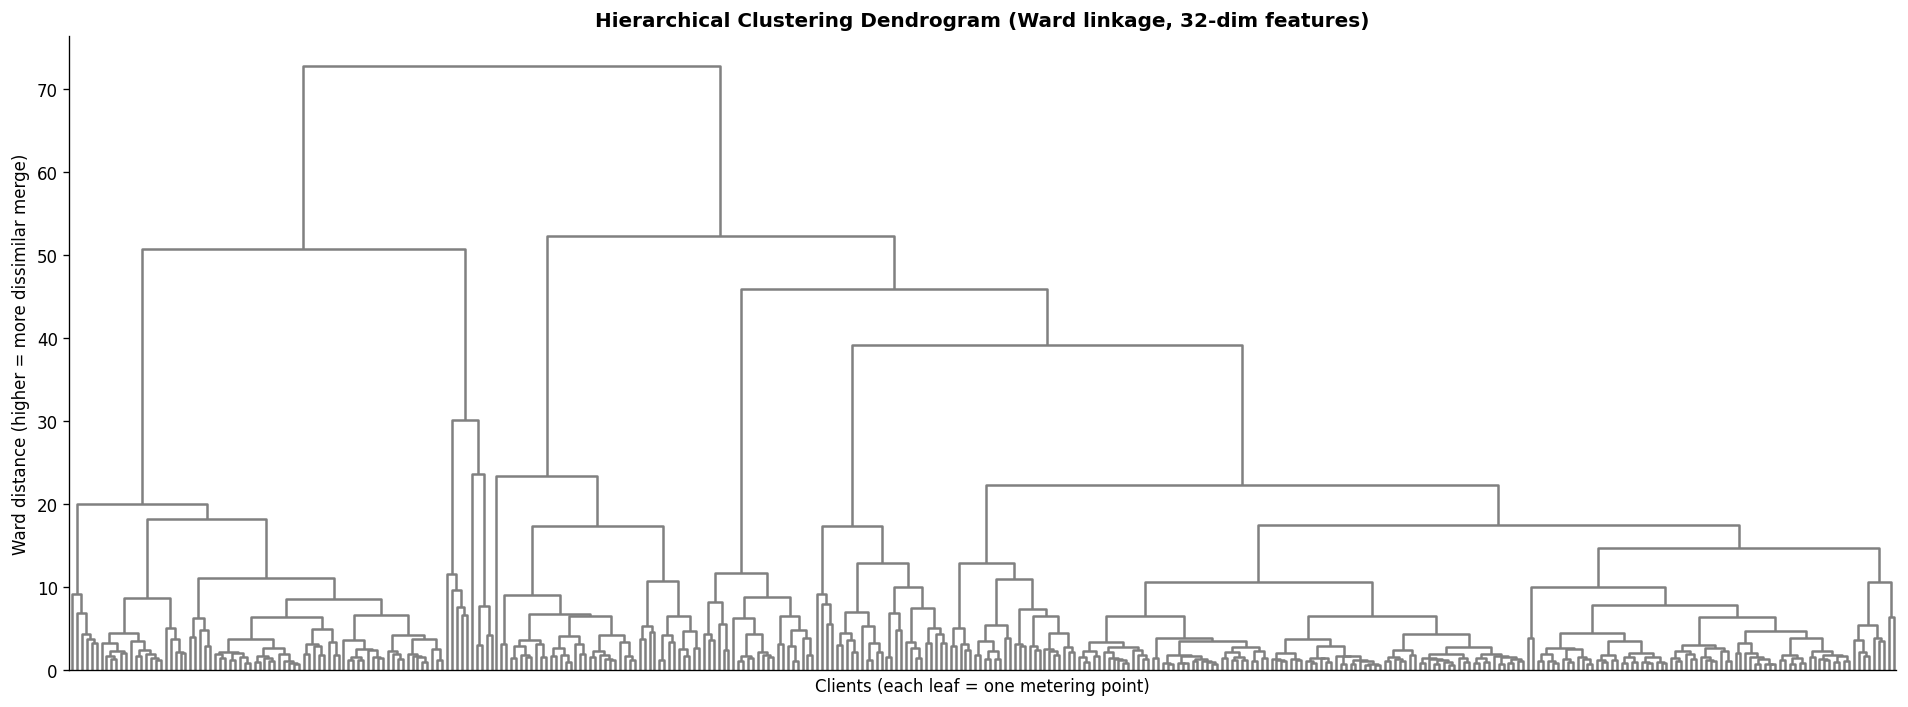

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

# Compute linkage on all 32 scaled features.
# Ward linkage minimizes within-cluster variance at each merge step —
# it tends to produce compact, similarly-sized clusters, which is what we want.
Z = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(16, 6))

dendrogram(
    Z,
    ax=ax,
    no_labels=True,       # 370 client labels would be unreadable
    color_threshold=0,    # we'll draw our own cut line
    above_threshold_color="grey",
    leaf_font_size=6,
)

# The natural k is where the dendrogram has the longest vertical lines before merging —
# those long gaps represent big jumps in within-cluster variance (i.e., forced merges of dissimilar groups).
# Draw a horizontal line at the cut height you choose to read off k visually.
CUT_HEIGHT = None   # <-- set this after inspecting the plot; e.g. CUT_HEIGHT = 80
if CUT_HEIGHT:
    ax.axhline(CUT_HEIGHT, color="red", linestyle="--", linewidth=1.5, label=f"cut at {CUT_HEIGHT}")
    ax.legend()

ax.set_title("Hierarchical Clustering Dendrogram (Ward linkage, 32-dim features)", fontweight="bold")
ax.set_xlabel("Clients (each leaf = one metering point)")
ax.set_ylabel("Ward distance (higher = more dissimilar merge)")
plt.tight_layout()
plt.show()

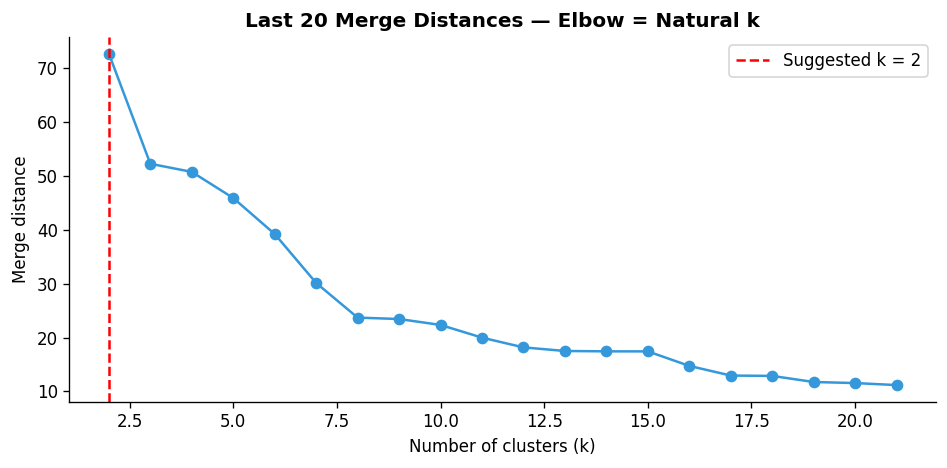

Suggested k from largest merge gap: 2


In [ ]:
# Plot the merge distances (last 20 merges) to find the biggest jump —
# the elbow here corresponds to the same cut point as the longest gap in the dendrogram.
# The k just before the biggest jump is the natural number of clusters.

last_merges = Z[-20:, 2][::-1]   # heights of the last 20 merges, reversed (top-down)
merge_idx   = np.arange(2, 22)    # k = 2 to 21

gaps = np.diff(last_merges[::-1])[::-1]   # gap between consecutive merge heights
suggested_k = int(merge_idx[np.argmax(gaps)])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(merge_idx, last_merges, "o-", color="#3498db", linewidth=1.5)
ax.axvline(suggested_k, color="red", linestyle="--", linewidth=1.5, label=f"Suggested k = {suggested_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Merge distance")
ax.set_title("Last 20 Merge Distances — Elbow = Natural k", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Suggested k from largest merge gap: {suggested_k}")

### 4b. K-Means on 24-dim Normalized Hourly Profiles

Use `suggested_k` from the dendrogram. Cluster only on the hourly shape features so that:
- Cluster centroids are 24-hour load profiles — directly plottable and interpretable
- Magnitude differences don't drive assignment (profiles are already row-normalized)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Use k from dendrogram; override manually if the dendrogram suggests something unreasonable
K = 4   # performed the best out of the elbows

# K-Means on the 24-dim normalized profiles only (not the full 32-dim matrix)
# n_init=20: run 20 random initializations and keep the best — reduces sensitivity to init
profile_features = hourly_profile_norm.loc[X_scaled.index]   # align index after dropna

kmeans = KMeans(n_clusters=K, n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(profile_features)

# Attach cluster assignments back to the feature matrix for later use
feature_matrix["cluster"] = cluster_labels
profile_features = profile_features.copy()
profile_features["cluster"] = cluster_labels

print(f"K = {K}")
print("Cluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

K = 4
Cluster sizes:
0    215
1     35
2     91
3     29
Name: count, dtype: int64


In [ ]:
# save cluster for n8n

import json
import os

# Define the directory path
output_dir = "/electricity_forecasting/apis/"

# Create the directory if it does not exist
os.makedirs(output_dir, exist_ok=True)

mapping = feature_matrix["cluster"].to_dict()
mapping_serializable = {str(k): int(v) for k, v in mapping.items()}

# Construct the full file path
file_path = os.path.join(output_dir, "cluster_mapping.json")

with open(file_path, "w") as f:
    json.dump(mapping_serializable, f, indent=2)

print(f"Saved {len(mapping_serializable)} client mappings to {file_path}")

Saved 370 client mappings to /electricity_forecasting/apis/cluster_mapping.json


### 4c. Validation — Silhouette Scores + Cluster Load Profiles

Overall silhouette score: 0.439

Per-cluster mean silhouette:
cluster
0    0.488
1    0.475
2    0.292
3    0.497
Name: silhouette, dtype: float64


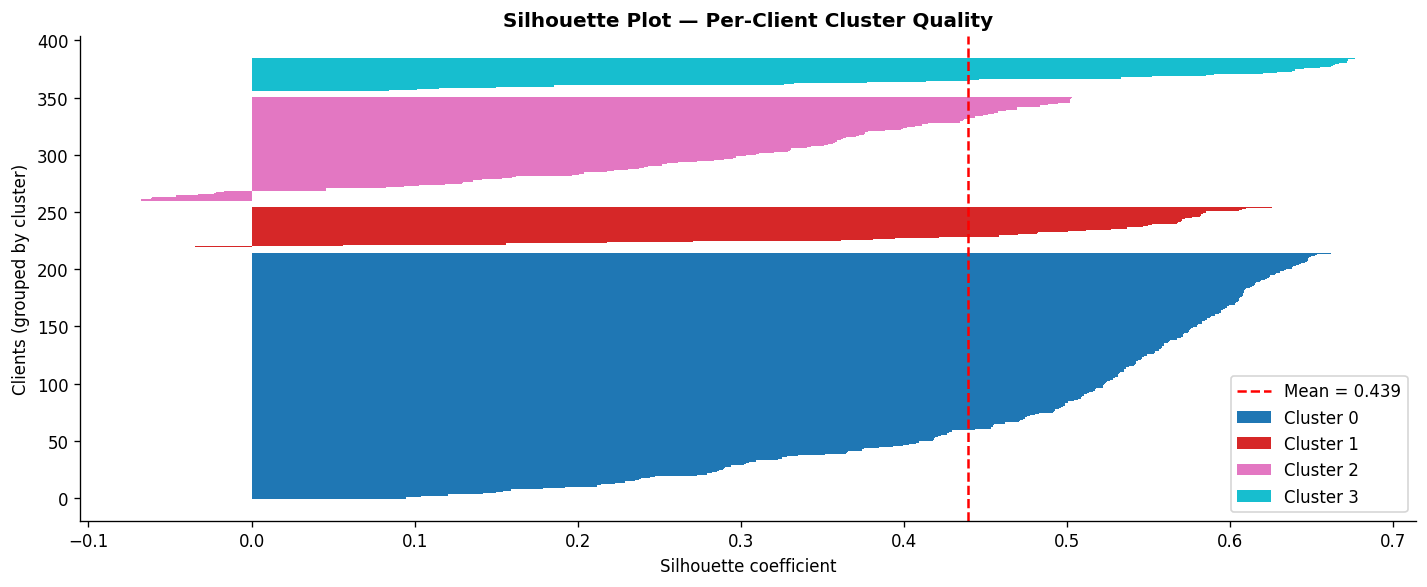

In [ ]:
# Silhouette score: measures how well each client fits its own cluster vs. the nearest other cluster.
# Range: -1 (wrong cluster) to +1 (perfectly separated). Above 0.3 is generally acceptable.
# Per-sample scores reveal which clients are borderline (near 0) vs. confidently assigned (near 1).

X_profile = profile_features.drop(columns="cluster")
overall_sil = silhouette_score(X_profile, cluster_labels)
sample_sil  = silhouette_samples(X_profile, cluster_labels)

print(f"Overall silhouette score: {overall_sil:.3f}")

# Per-cluster silhouette breakdown
sil_df = pd.DataFrame({"client": X_profile.index, "cluster": cluster_labels, "silhouette": sample_sil})
print("\nPer-cluster mean silhouette:")
print(sil_df.groupby("cluster")["silhouette"].mean().round(3))

# Silhouette plot: each bar is one client, sorted by cluster then score.
# Thin clusters with many negative bars → consider merging them.
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, K))
y_lower = 0
for c in range(K):
    c_sil = np.sort(sil_df[sil_df["cluster"] == c]["silhouette"].values)
    y_upper = y_lower + len(c_sil)
    ax.barh(range(y_lower, y_upper), c_sil, height=1.0, color=colors[c], edgecolor="none", label=f"Cluster {c}")
    y_lower = y_upper + 5   # gap between clusters

ax.axvline(overall_sil, color="red", linestyle="--", linewidth=1.5, label=f"Mean = {overall_sil:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Clients (grouped by cluster)")
ax.set_title("Silhouette Plot — Per-Client Cluster Quality", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

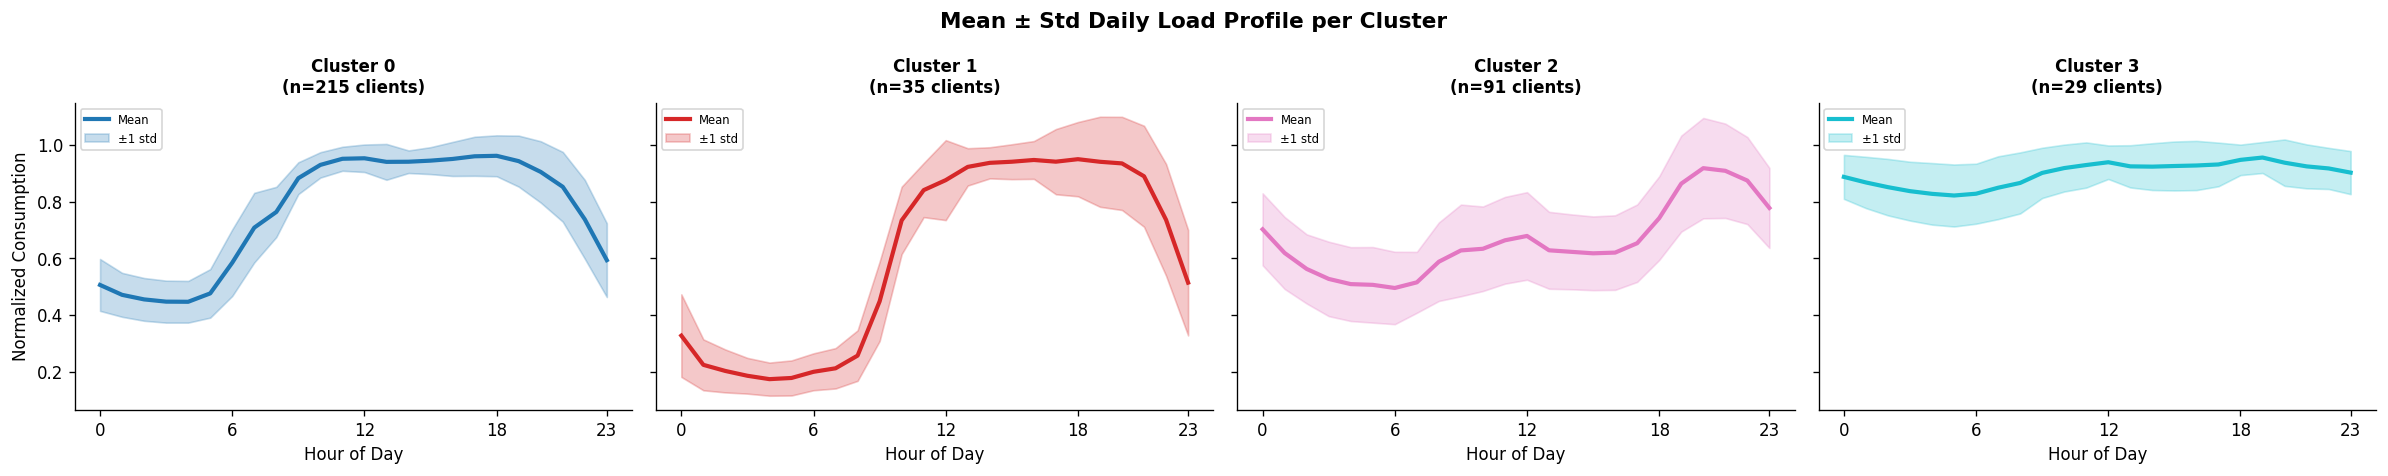

In [ ]:
# Mean ± std load profile per cluster — the key interpretability plot.
# The centroid (mean line) shows the typical daily shape for that cluster.
# The shaded band (±1 std) shows how tightly clients in the cluster agree on that shape.
# Narrow band → homogeneous cluster. Wide band → consider splitting further.

hours = np.arange(24)
fig, axes = plt.subplots(1, K, figsize=(5 * K, 4), sharey=True)
if K == 1:
    axes = [axes]

for c, ax in enumerate(axes):
    members = X_profile[cluster_labels == c]
    mean_profile = members.mean()
    std_profile  = members.std()
    n_members    = len(members)

    ax.plot(hours, mean_profile, color=colors[c], linewidth=2.5, label="Mean")
    ax.fill_between(
        hours,
        mean_profile - std_profile,
        mean_profile + std_profile,
        alpha=0.25, color=colors[c], label="±1 std"
    )
    ax.set_title(f"Cluster {c}\n(n={n_members} clients)", fontsize=10, fontweight="bold")
    ax.set_xlabel("Hour of Day")
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.legend(fontsize=7)
    if c == 0:
        ax.set_ylabel("Normalized Consumption")

fig.suptitle("Mean ± Std Daily Load Profile per Cluster", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

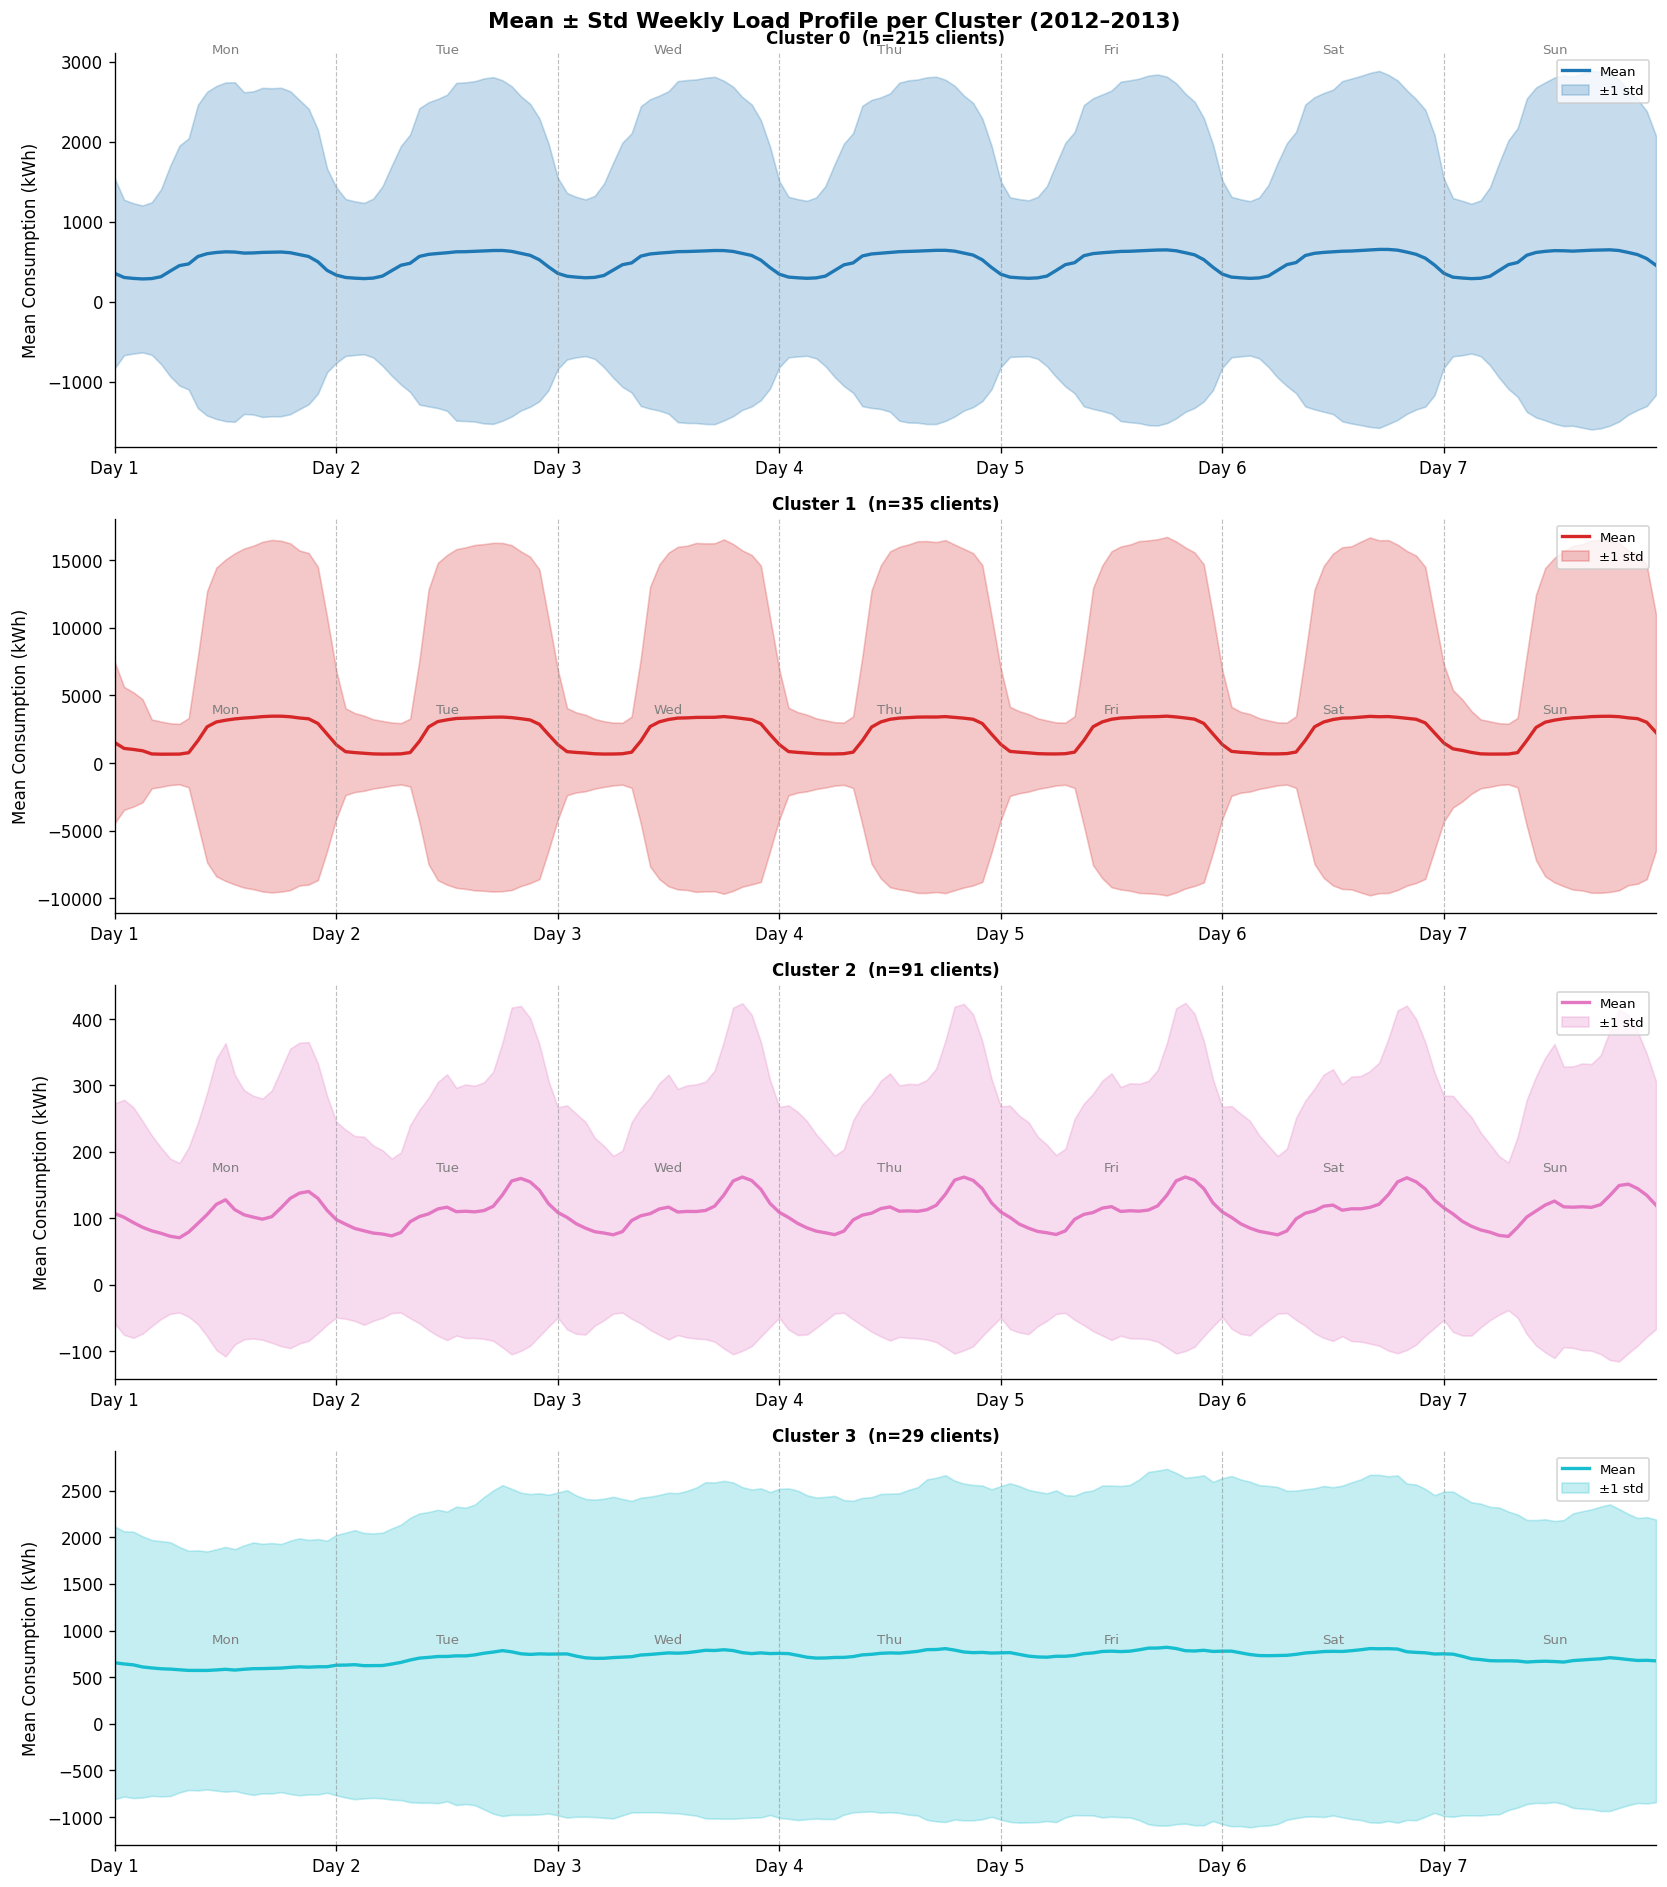

In [ ]:
# Weekly load profile per cluster (168h), 4 clusters stacked vertically

hours = np.arange(168)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(K, 1, figsize=(14, 4 * K))

if K == 1:
    axes = [axes]

TRAIN_END = "2013-12-31 23:00"
TEST_START = "2014-01-01 00:00"
TEST_END   = "2014-12-31 23:00"

for c, ax in enumerate(axes):
    # Build weekly profiles: reshape each client's normalized profile into (n_weeks, 168)
    members = feature_matrix[feature_matrix["cluster"] == c].index.tolist()
    client_data = df_hourly[members].loc[:TRAIN_END]

    n_complete_weeks = len(client_data) // 168
    weekly_profiles = []
    for client in members:
        s = client_data[client].values[:n_complete_weeks * 168]
        weeks = s.reshape(n_complete_weeks, 168)
        weekly_profiles.append(weeks.mean(axis=0))  # mean week per client

    weekly_profiles = np.array(weekly_profiles)  # (M_c, 168)
    mean_profile = weekly_profiles.mean(axis=0)
    std_profile  = weekly_profiles.std(axis=0)

    ax.plot(hours, mean_profile, color=colors[c], linewidth=2, label="Mean")
    ax.fill_between(hours,
                    mean_profile - std_profile,
                    mean_profile + std_profile,
                    alpha=0.25, color=colors[c], label="±1 std")

    # Day separator lines and labels
    for d in range(1, 7):
        ax.axvline(d * 24, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
    for d, label in enumerate(day_labels):
        ax.text(d * 24 + 12, ax.get_ylim()[1] if c == 0 else mean_profile.max() * 1.05,
                label, ha='center', fontsize=8, color='gray')

    ax.set_title(f"Cluster {c}  (n={len(members)} clients)", fontsize=10, fontweight="bold")
    ax.set_ylabel("Mean Consumption (kWh)")
    ax.set_xlim(0, 167)
    ax.set_xticks([d * 24 for d in range(7)])
    ax.set_xticklabels([f"Day {d+1}" for d in range(7)])
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle("Mean ± Std Weekly Load Profile per Cluster (2012–2013)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# Cluster summary table — mean of original (non-scaled) features per cluster.
# Use this to give each cluster a human-readable label, e.g.:
#   "High weekend ratio + low ACF lag24 → irregular residential"
#   "Low weekend ratio + high seasonal strength → regular commercial"

summary_cols = ["mean_kwh", "cv", "peak_to_mean", "weekend_wd_ratio",
                "acf_lag24", "acf_lag168", "seasonal_strength", "residual_cv"]

cluster_summary = (
    feature_matrix[summary_cols + ["cluster"]]
    .groupby("cluster")
    .mean()
    .round(3)
)
cluster_summary.index = [f"Cluster {c}" for c in cluster_summary.index]
cluster_summary

,mean_kwh,cv,peak_to_mean,weekend_wd_ratio,acf_lag24,acf_lag168,seasonal_strength,residual_cv
Cluster 0,509.395,0.495,2.767,0.959,0.919,0.914,0.888,0.111
Cluster 1,2169.079,0.694,3.475,1.003,0.946,0.920,0.928,0.185
Cluster 2,111.197,0.580,4.893,1.028,0.817,0.841,0.771,0.210
Cluster 3,836.493,0.496,3.251,0.918,0.796,0.815,0.461,0.120


## 5. Build Models

1. Compute cluster mean series for each cluster
2. Naive baselines (seasonal naive, daily mean profile) — no fitting, quick to compute
3. SARIMA per cluster — fixed order (1,1,1)(1,1,1,24) from existing work
4. Evaluate all three with sliding window (96h lookback, 24h forecast) per cluster
5. Compare per-cluster SARIMA vs. global SARIMA as a sanity check
6. Then introduce BasisFormer / transformer models as the "improved" tier


### 5.1 Cluster Mean Series & Helper Functions

In [ ]:
# One series per cluster: average kWh across all member clients at each hour.
# Smoother and less noisy than individual clients — better for model fitting.

cluster_series = {}
for c in sorted(feature_matrix["cluster"].unique()):
    members = feature_matrix[feature_matrix["cluster"] == c].index
    cluster_series[c] = df_hourly[members].mean(axis=1)
    print(f"Cluster {c}: {len(members)} clients, series length {len(cluster_series[c])}")


Cluster 0: 215 clients, series length 26304
Cluster 1: 35 clients, series length 26304
Cluster 2: 91 clients, series length 26304
Cluster 3: 29 clients, series length 26304


In [ ]:
# Temporal split: train on 2012–2013, test on 2014.
# Never shuffle time series — future data must never leak into training.

TRAIN_END = "2013-12-31 23:00"
TEST_START = "2014-01-01 00:00"
TEST_END   = "2014-12-31 23:00"

train_series = {c: s.loc[:TRAIN_END]          for c, s in cluster_series.items()}
test_series  = {c: s.loc[TEST_START:TEST_END] for c, s in cluster_series.items()}

print(f"Train length: {len(next(iter(train_series.values())))} hours")
print(f"Test length:  {len(next(iter(test_series.values())))} hours")


Train length: 17544 hours
Test length:  8760 hours


In [ ]:
def mape(actual, predicted, eps=0.1):
    """MAPE with a floor on the denominator to avoid explosion near zero."""
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / np.maximum(np.abs(actual), eps))) * 100

def smape(actual, predicted):
    """Symmetric MAPE — bounded [0, 200%], handles near-zero actuals gracefully."""
    actual, predicted = np.array(actual), np.array(predicted)
    denom = (np.abs(actual) + np.abs(predicted)) / 2
    mask = denom != 0
    return np.mean(np.abs(actual[mask] - predicted[mask]) / denom[mask]) * 100

def mae(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs(actual - predicted))

def rmse(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    return np.sqrt(np.mean((actual - predicted) ** 2))

def sliding_window_eval(series_train, series_test, forecast_fn, horizon=24, n_windows=30):
    test_len = len(series_test)
    window_starts = np.linspace(0, test_len - horizon - 1, n_windows, dtype=int)

    metrics = {"mape": [], "smape": [], "mae": [], "rmse": []}
    for start in window_starts:
        actual    = series_test.iloc[start : start + horizon].values
        predicted = forecast_fn(series_train, series_test.iloc[:start], horizon)
        if predicted is not None:
            metrics["mape"].append(mape(actual, predicted))
            metrics["smape"].append(smape(actual, predicted))
            metrics["mae"].append(mae(actual, predicted))
            metrics["rmse"].append(rmse(actual, predicted))

    return {k: round(float(np.mean(v)), 3) for k, v in metrics.items()}


### 5.2 Naive Baseline

In [ ]:
# --- Baseline 1: Seasonal Naive ---
# Predict using the value from exactly 168 hours ago (same hour, one week prior).
# If the test window is too early to have a full week of history, falls back to 24h prior.
# Hard to beat for electricity because weekly patterns are strong.

def seasonal_naive_forecast(train, history, horizon=24, season=168):
    combined = pd.concat([train, history])
    if len(combined) < season:
        season = 24   # fall back to daily if not enough history
    return combined.iloc[-season : -season + horizon].values

# --- Baseline 2: Daily Mean Profile ---
# Predict using the cluster's average consumption at each hour of the day, computed from training data.
# Purely static — ignores recent trends entirely, but captures the dominant daily shape.

def make_daily_profile_forecast(train):
    profile = train.groupby(train.index.hour).mean().values   # shape: (24,)
    def forecast_fn(tr, history, horizon=24):
        # Roll the 24-hour profile to start from the next hour after history ends
        if len(history) > 0:
            next_hour = (history.index[-1].hour + 1) % 24
        else:
            next_hour = (tr.index[-1].hour + 1) % 24
        indices = [(next_hour + h) % 24 for h in range(horizon)]
        return profile[indices]
    return forecast_fn

# All possible 24h windows in the 2014 test set
# test_len=8760, horizon=24 → 8736 possible start positions

naive_full_results = {}

for c in cluster_series:
    tr, te = train_series[c], test_series[c]
    n_all = len(te) - 24   # 8736

    dp_fn = make_daily_profile_forecast(tr)

    sn_m = sliding_window_eval(tr, te,
               lambda tr, hist, h: seasonal_naive_forecast(tr, hist, h),
               n_windows=n_all)
    dp_m = sliding_window_eval(tr, te, dp_fn, n_windows=n_all)

    naive_full_results[c] = {
        "sn_mape":  sn_m["mape"],  "sn_smape":  sn_m["smape"],
        "sn_mae":   sn_m["mae"],   "sn_rmse":   sn_m["rmse"],
        "dp_mape":  dp_m["mape"],  "dp_smape":  dp_m["smape"],
        "dp_mae":   dp_m["mae"],   "dp_rmse":   dp_m["rmse"],
    }
    print(f"Cluster {c} | SN  — MAPE={sn_m['mape']:.2f}%  sMAPE={sn_m['smape']:.2f}%  MAE={sn_m['mae']:.3f}  (n={n_all} windows)")
    print(f"          | DP  — MAPE={dp_m['mape']:.2f}%  sMAPE={dp_m['smape']:.2f}%  MAE={dp_m['mae']:.3f}")


Cluster 0 | SN  — MAPE=6.41%  sMAPE=4.42%  MAE=22.979  (n=8736 windows)
          | DP  — MAPE=10.11%  sMAPE=7.87%  MAE=40.769
Cluster 1 | SN  — MAPE=11.16%  sMAPE=7.80%  MAE=206.780  (n=8736 windows)
          | DP  — MAPE=31.16%  sMAPE=24.95%  MAE=583.767
Cluster 2 | SN  — MAPE=15.11%  sMAPE=4.89%  MAE=5.461  (n=8736 windows)
          | DP  — MAPE=20.93%  sMAPE=9.51%  MAE=10.796
Cluster 3 | SN  — MAPE=117.41%  sMAPE=9.27%  MAE=93.764  (n=8736 windows)
          | DP  — MAPE=115.13%  sMAPE=39.17%  MAE=361.317


### 5.3 SARIMA per cluster

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fixed order from existing notebook: SARIMA(1,1,1)(1,0,1,24)
# Best performer on day-ahead sliding window evaluation in project_arima_combined.
# Fit once on the full training series per cluster — avoids the cost of refitting per window.

ORDER         = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 24)

sarima_models = {}
sarima_results = {}

for c in cluster_series:
    tr, te = train_series[c], test_series[c]
    print(f"Fitting SARIMA for Cluster {c}...")

    model = SARIMAX(tr, order=ORDER, seasonal_order=SEASONAL_ORDER,
                    enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    sarima_models[c] = fit

    # Forecast function: extends the fitted model into the test period step by step
    def make_sarima_forecast(fitted_model, full_train):
        def forecast_fn(tr, history, horizon=24):
            # Apply the fitted model to data up to this point in the test set
            n_history = len(history)
            try:
                updated = fitted_model.apply(pd.concat([full_train, history]))
                forecast = updated.forecast(steps=horizon)
                return forecast.values
            except Exception:
                return None
        return forecast_fn

    sarima_fn      = make_sarima_forecast(fit, tr)
    sarima_metrics = sliding_window_eval(tr, te, sarima_fn)
    sarima_results[c] = {
        "sarima_mape":  sarima_metrics["mape"],  "sarima_smape": sarima_metrics["smape"],
        "sarima_mae":   sarima_metrics["mae"],   "sarima_rmse":  sarima_metrics["rmse"],
    }
    print(f"  Cluster {c} SARIMA — MAPE: {sarima_metrics['mape']:.2f}%  sMAPE: {sarima_metrics['smape']:.2f}%  MAE: {sarima_metrics['mae']:.3f}  RMSE: {sarima_metrics['rmse']:.3f}")


Fitting SARIMA for Cluster 0...
  Cluster 0 SARIMA — MAPE: 29.15%  sMAPE: 4.97%  MAE: 21.569  RMSE: 27.632
Fitting SARIMA for Cluster 1...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Cluster 1 SARIMA — MAPE: 47.27%  sMAPE: 12.90%  MAE: 183.165  RMSE: 231.993
Fitting SARIMA for Cluster 2...
  Cluster 2 SARIMA — MAPE: 136.16%  sMAPE: 7.00%  MAE: 7.530  RMSE: 9.173
Fitting SARIMA for Cluster 3...
  Cluster 3 SARIMA — MAPE: 1227.37%  sMAPE: 7.14%  MAE: 71.828  RMSE: 89.020


In [ ]:
# Combine all results into one table.
results = pd.DataFrame({
    c: {**naive_results[c], **sarima_results[c]}
    for c in cluster_series
}).T
results.index = [f"Cluster {c}" for c in results.index]

# Reorder columns by metric type for easy reading
results = results[[
    "sn_mape",  "sn_smape",  "sn_mae",  "sn_rmse",
    "dp_mape",  "dp_smape",  "dp_mae",  "dp_rmse",
    "sarima_mape", "sarima_smape", "sarima_mae", "sarima_rmse",
]]
results.columns = [
    "SN MAPE", "SN sMAPE", "SN MAE", "SN RMSE",
    "DP MAPE", "DP sMAPE", "DP MAE", "DP RMSE",
    "SARIMA MAPE", "SARIMA sMAPE", "SARIMA MAE", "SARIMA RMSE",
]

# Best baseline per metric (min across seasonal naive and daily profile)
for metric in ["MAPE", "sMAPE", "MAE", "RMSE"]:
    results[f"Best Baseline {metric}"] = results[[f"SN {metric}", f"DP {metric}"]].min(axis=1)
    results[f"SARIMA vs Baseline {metric}"] = (results[f"SARIMA {metric}"] - results[f"Best Baseline {metric}"]).round(3)

print(results.to_string())


            SN MAPE  SN sMAPE   SN MAE  SN RMSE   DP MAPE  DP sMAPE   DP MAE  DP RMSE  SARIMA MAPE  SARIMA sMAPE  SARIMA MAE  SARIMA RMSE  Best Baseline MAPE  SARIMA vs Baseline MAPE  Best Baseline sMAPE  SARIMA vs Baseline sMAPE  Best Baseline MAE  SARIMA vs Baseline MAE  Best Baseline RMSE  SARIMA vs Baseline RMSE
Cluster 0    27.961     4.562   23.406   29.672    36.770     9.346   46.656   54.593       29.149         4.967      21.569       27.632              27.961                    1.188                4.562                     0.405             23.406                  -1.837              29.672                   -2.040
Cluster 1    47.949     8.227  222.284  313.055    69.044    26.371  617.590  761.838       45.336        12.652     179.472      228.613              47.949                   -2.613                8.227                     4.425            222.284                 -42.812             313.055                  -84.442
Cluster 2   128.853     4.835    5.182    6.42

## 5.4 Facebook Prophet

In [ ]:
from prophet import Prophet

prophet_models  = {}
prophet_results = {}

def make_prophet_fn(model):
    def prophet_forecast_fn(train, history, horizon=24):
        combined_df = pd.concat([
            train.reset_index(name='y'),
            history.reset_index(name='y')
        ]).rename(columns={'index': 'ds'})
        future_start = combined_df['ds'].iloc[-1] + pd.Timedelta(hours=1)
        future_df = pd.DataFrame({'ds': pd.date_range(start=future_start, periods=horizon, freq='h')})
        forecast = model.predict(future_df)
        return forecast['yhat'].values
    return prophet_forecast_fn

for c in cluster_series:
    df_p = train_series[c].reset_index()
    df_p.columns = ['ds', 'y']
    m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
    m.add_country_holidays(country_name='PT')
    m.fit(df_p)
    prophet_models[c] = m

    fn = make_prophet_fn(m)

    p_metrics = sliding_window_eval(train_series[c], test_series[c], fn, n_windows=365)
    prophet_results[c] = {
        "prophet_mape":  p_metrics["mape"],
        "prophet_smape": p_metrics["smape"],
        "prophet_mae":   p_metrics["mae"],
        "prophet_rmse":  p_metrics["rmse"],
    }
    print(f"Cluster {c} Prophet — MAPE: {p_metrics['mape']:.2f}%  sMAPE: {p_metrics['smape']:.2f}%  MAE: {p_metrics['mae']:.3f}  RMSE: {p_metrics['rmse']:.3f}")


Cluster 0 Prophet — MAPE: 50.19%  sMAPE: 72.19%  MAE: 236.526  RMSE: 238.235
Cluster 1 Prophet — MAPE: 258.08%  sMAPE: 166.42%  MAE: 3198.828  RMSE: 3253.160
Cluster 2 Prophet — MAPE: 42.40%  sMAPE: 24.63%  MAE: 30.532  RMSE: 32.048
Cluster 3 Prophet — MAPE: 121.17%  sMAPE: 78.42%  MAE: 578.988  RMSE: 582.851


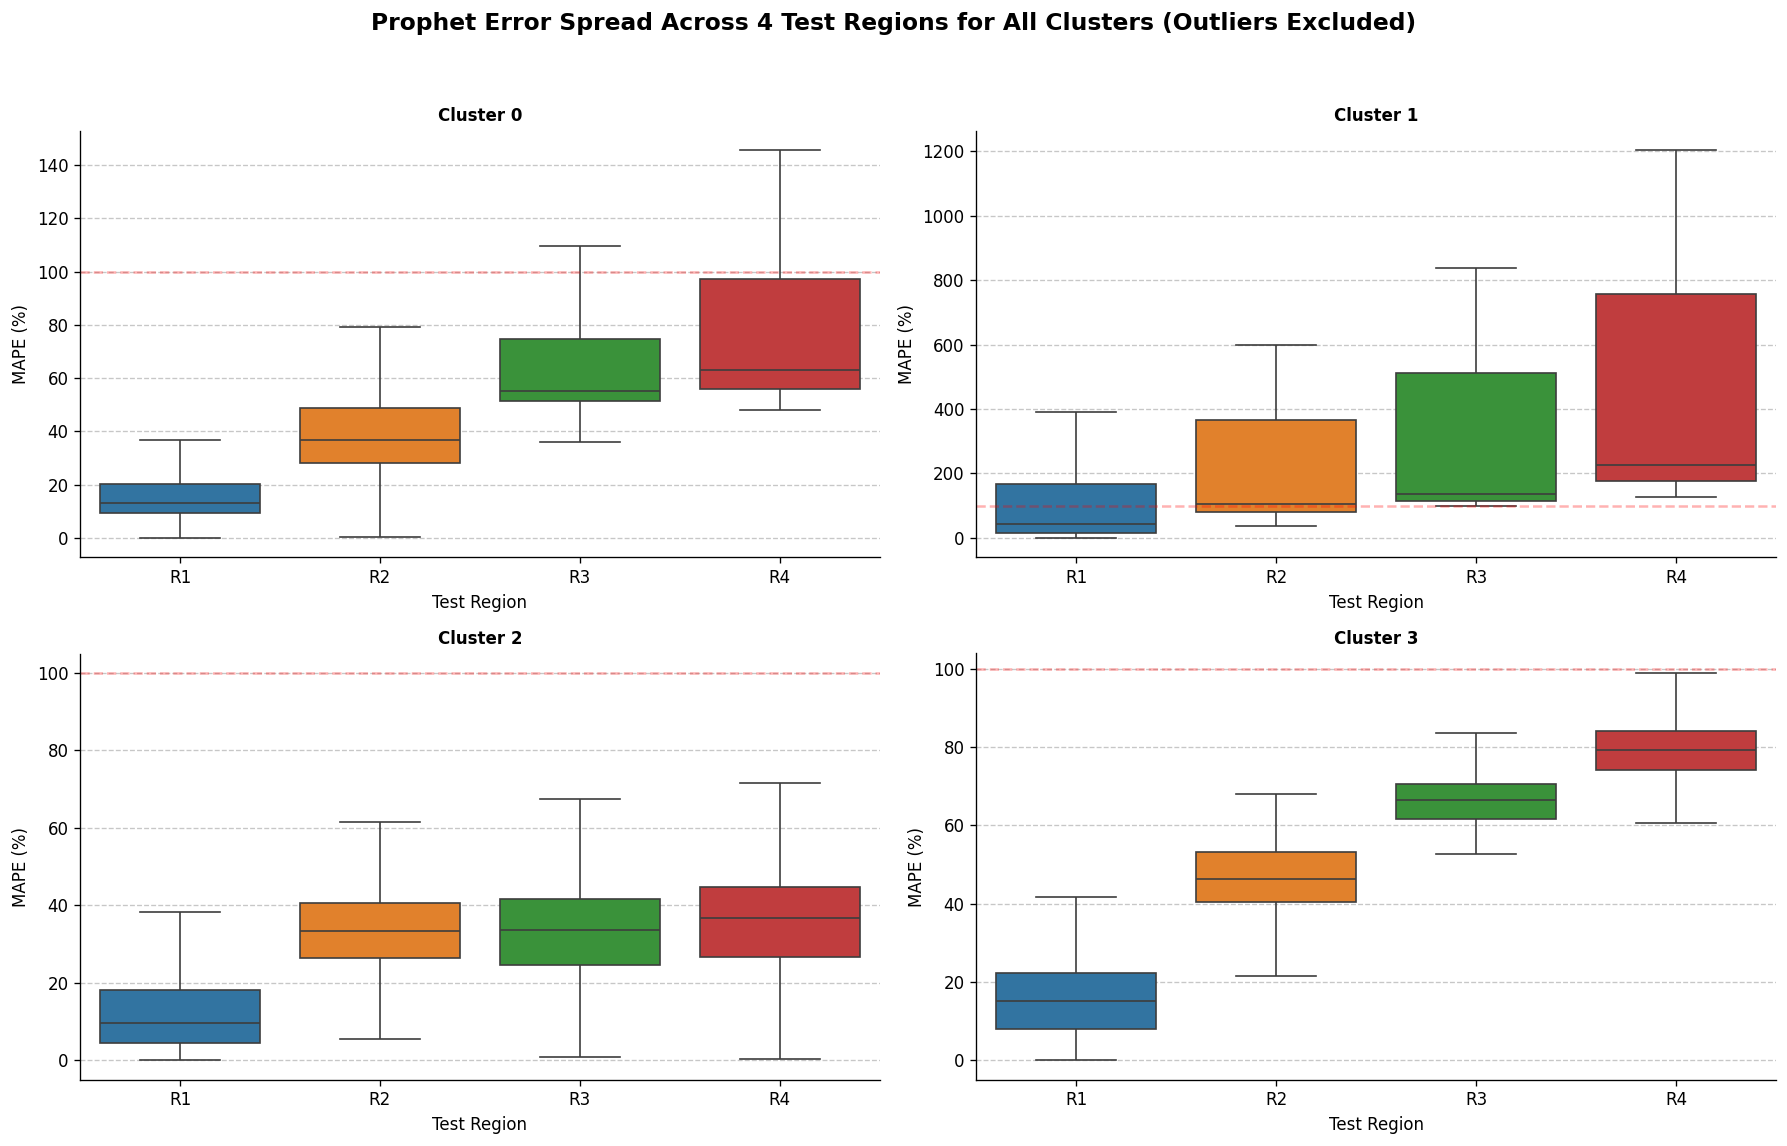

In [ ]:
def get_prophet_regional_errors(cluster_id, n_windows=365):
    tr = train_series[cluster_id]
    te = test_series[cluster_id]
    fn = make_prophet_fn(prophet_models[cluster_id])  # fix closure bug

    test_len = len(te)
    horizon = 24
    window_starts = np.linspace(0, test_len - horizon - 1, n_windows, dtype=int)

    all_window_apes = []

    for start in window_starts:
        actual    = te.iloc[start : start + horizon].values
        predicted = fn(tr, te.iloc[:start], horizon)

        ape = np.abs((actual - predicted) / np.maximum(np.abs(actual), 0.1)) * 100
        all_window_apes.append(ape.flatten())

    total_errors = np.concatenate(all_window_apes)

    # Exclude extreme outliers (MAPE > 10000%)
    total_errors = total_errors[total_errors <= 10000]

    # Divide into 4 equal regions
    region_size = len(total_errors) // 4
    regions = [total_errors[i*region_size : (i+1)*region_size] for i in range(4)]
    return regions

# --- Generate and Plot for Prophet for all clusters ---

K = 4 # Number of clusters
NUM_REGIONS = 4 # Number of regions to divide the errors into

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=False) # Changed sharey=True to sharey=False
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, cluster_id in enumerate(sorted(prophet_models.keys())):
    ax = axes[i]
    prophet_regions_data = get_prophet_regional_errors(cluster_id=cluster_id)

    if prophet_regions_data:
        sns.boxplot(data=prophet_regions_data, ax=ax, showfliers=False) # showfliers=False to exclude far outliers from view
        ax.set_title(f"Cluster {cluster_id}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Test Region")
        ax.set_xticks(range(NUM_REGIONS), [f'R{j+1}' for j in range(NUM_REGIONS)])
        ax.axhline(100, color='red', linestyle='--', alpha=0.3, label="100% Error Threshold")
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.set_ylabel("MAPE (%)") # Always set y-label for each subplot
    else:
        ax.set_title(f"Cluster {cluster_id} (No data)", fontsize=10, fontweight="bold")
        ax.set_xlabel("Test Region")

fig.suptitle(f"Prophet Error Spread Across {NUM_REGIONS} Test Regions for All Clusters (Outliers Excluded)", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 5.5 Gradient Boosting

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

# ── 1. Train one GB model per cluster on cluster mean ──

GB_MODEL_PARAMS = dict(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=150,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    random_state=42
)

gb_cluster_models = {}

for c in range(K):
    s = train_series[c]  # cluster mean, pd.Series with DatetimeIndex

    rows = []
    for i in range(168, len(s)):
        hist = s.iloc[i-168:i]
        rows.append({
            'lag_1':        hist.iloc[-1],
            'lag_24':       hist.iloc[-24],
            'lag_168':      hist.iloc[-168],
            'roll_mean_24': hist.iloc[-24:].mean(),
            'roll_std_24':  hist.iloc[-24:].std(),
            'hour':         s.index[i].hour,
            'dow':          s.index[i].dayofweek,
            'month':        s.index[i].month,
            'is_weekend':   int(s.index[i].dayofweek >= 5),
            'y':            s.iloc[i]
        })

    df_c = pd.DataFrame(rows)
    X = df_c.drop(columns='y')
    y = np.log1p(df_c['y'])

    model = HistGradientBoostingRegressor(**GB_MODEL_PARAMS)
    model.fit(X, y)
    gb_cluster_models[c] = model
    print(f"Cluster {c} trained.")


Cluster 0 trained.
Cluster 1 trained.
Cluster 2 trained.
Cluster 3 trained.


In [ ]:
import joblib, os

GB_MODEL_DIR = "/content/models"

# Save only cluster 1 since that's your chosen GB cluster
save_dir = f"{GB_MODEL_DIR}/cluster_1"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(gb_cluster_models[1], f"{save_dir}/gb_model.pkl")

# Save the cluster mean training series so the API can reconstruct features
train_series[1].to_csv(f"{save_dir}/train_series.csv")
test_series[1].to_csv(f"{save_dir}/test_series.csv")

print("Saved GB model for cluster 1")

Saved GB model for cluster 1


In [ ]:
# ── 2. Forecast function + 365-window evaluation ──

def make_gb_cluster_forecast_fn(model, cluster_id, seq_len=168):
    train_mean = train_series[cluster_id].values
    test_mean  = test_series[cluster_id].values
    full_mean  = np.concatenate([train_mean, test_mean])
    full_index = train_series[cluster_id].index.append(test_series[cluster_id].index)

    def build_features(history, timestamp):
        return {
            'lag_1':        history[-1]   if len(history) >= 1   else history[0],
            'lag_24':       history[-24]  if len(history) >= 24  else history[0],
            'lag_168':      history[-168] if len(history) >= 168 else history[0],
            'roll_mean_24': history[-24:].mean() if len(history) >= 24 else history.mean(),
            'roll_std_24':  history[-24:].std()  if len(history) >= 24 else history.std(),
            'hour':         timestamp.hour,
            'dow':          timestamp.dayofweek,
            'month':        timestamp.month,
            'is_weekend':   int(timestamp.dayofweek >= 5),
        }

    def forecast_fn(series_train, history, horizon=24):
        pos = len(train_mean) + len(history)
        window = full_mean[max(0, pos - seq_len): pos]
        start_ts = full_index[pos]
        preds = []
        window_ext = window.copy()
        for step in range(horizon):
            ts = start_ts + pd.Timedelta(hours=step)
            feats = build_features(window_ext, ts)
            feat_arr = np.array(list(feats.values())).reshape(1, -1)
            p = max(np.expm1(model.predict(feat_arr)[0]), 0.0)
            preds.append(p)
            window_ext = np.append(window_ext[1:], p)
        return np.array(preds)

    return forecast_fn


gb_results = {}
for c in range(K):
    fn = make_gb_cluster_forecast_fn(gb_cluster_models[c], c)
    res = sliding_window_eval(train_series[c], test_series[c], fn, n_windows=365)
    gb_results[c] = res
    print(f"Cluster {c} | MAPE={res['mape']:.2f}% sMAPE={res['smape']:.2f}%  MAE={res['mae']:.3f}  RMSE={res['rmse']:.3f}")


Cluster 0 | MAPE=4.59% sMAPE=2.65%  MAE=13.037  RMSE=16.554
Cluster 1 | MAPE=8.63% sMAPE=5.56%  MAE=117.998  RMSE=161.787
Cluster 2 | MAPE=14.59% sMAPE=3.83%  MAE=4.271  RMSE=5.396
Cluster 3 | MAPE=110.73% sMAPE=6.30%  MAE=63.746  RMSE=75.958


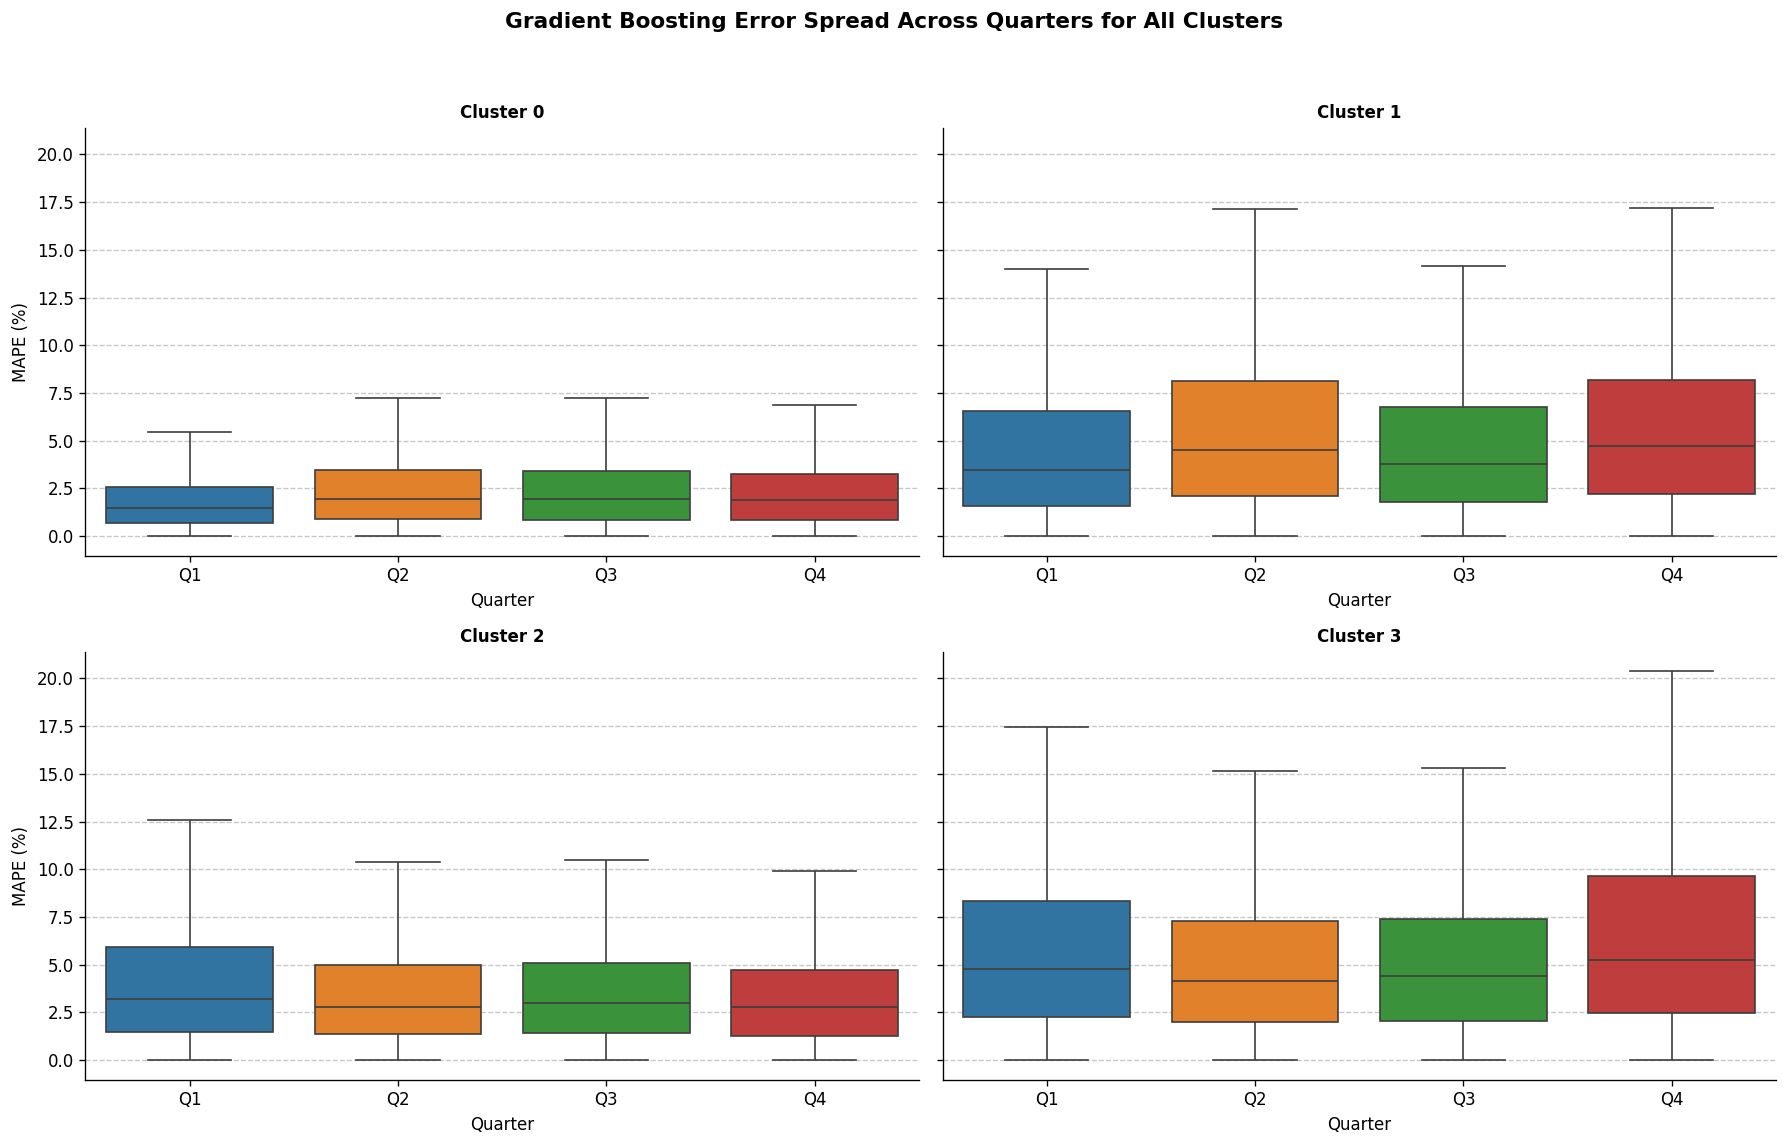

In [ ]:
# ── 3. MAPE box plots by quarter for all 4 clusters ──

def get_gb_regional_errors(cluster_id, n_windows=365, seq_len=168):
    fn = make_gb_cluster_forecast_fn(gb_cluster_models[cluster_id], cluster_id, seq_len=seq_len)
    tr = train_series[cluster_id]
    te = test_series[cluster_id]

    horizon  = 24
    test_len = len(te)
    window_starts = np.linspace(0, test_len - horizon - 1, n_windows, dtype=int)

    quarters = {f'Q{q}': [] for q in range(1, 5)}
    for start in window_starts:
        actual    = te.iloc[start: start + horizon].values
        predicted = fn(tr, te.iloc[:start], horizon)
        ape = np.abs((actual - predicted) / np.maximum(np.abs(actual), 0.1)) * 100
        ts = te.index[start]
        quarters[f'Q{ts.quarter}'].extend(ape.tolist())

    regions = []
    for q in ['Q1', 'Q2', 'Q3', 'Q4']:
        arr = np.array(quarters[q])
        regions.append(arr[arr <= 10000])
    return regions


fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axes = axes.flatten()

for i, c in enumerate(range(K)):
    ax = axes[i]
    regions = get_gb_regional_errors(cluster_id=c, n_windows=365)
    sns.boxplot(data=regions, ax=ax, showfliers=False)
    ax.set_title(f"Cluster {c}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Quarter")
    ax.set_xticks(range(4))
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if i % 2 == 0:
        ax.set_ylabel("MAPE (%)")

fig.suptitle("Gradient Boosting Error Spread Across Quarters for All Clusters",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 5.6 PatchTST — Channel-Independent Patch Time Series Transformer

Reference: Nie et al., ICLR 2023 — *A Time Series is Worth 64 Words*

**Key ideas:**
- **Patching**: 96h lookback split into overlapping patches (P=16, S=8) → 12 tokens per client
- **Channel-independence**: all M clients in a cluster share Transformer weights but are processed independently
- **Train on individual clients**: (T, M) matrix per cluster → far more training signal than the cluster mean alone
- **Evaluate on cluster mean**: predictions averaged across M clients → fair comparison with SARIMA / Naive / Prophet


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


class PatchTST(nn.Module):
    """
    Channel-independent Patch Time Series Transformer.
    Nie et al., ICLR 2023  (https://github.com/yuqinie98/PatchTST)

    Input  (B, M, L)  →  output  (B, M, T)
      B = batch size,  M = number of channels (clients),
      L = look-back window,  T = forecast horizon

    Steps (Figure 1b of the paper):
      1. Instance norm per channel
      2. Reshape (B,M,L) → (B*M, L)   [channel-independence]
      3. Pad stride copies of last value → unfold into patches  (B*M, N, P)
      4. Linear projection + learnable positional encoding  (B*M, N, D)
      5. Transformer encoder
      6. Flatten + linear head  (B*M, T)
      7. Reshape → (B, M, T)  then denorm
    """

    def __init__(
        self,
        seq_len   = 96,    # look-back window L
        pred_len  = 24,    # forecast horizon T
        patch_len = 16,    # patch length P
        stride    =  8,    # stride S  →  N = floor((L-P)/S)+2 = 12 patches
        d_model   = 128,   # hidden dim D
        n_heads   =   8,   # attention heads  (d_model must be divisible by n_heads)
        e_layers  =   3,   # encoder layers
        d_ff      = 256,   # feedforward inner dim
        dropout   = 0.2,
    ):
        super().__init__()
        self.seq_len   = seq_len
        self.pred_len  = pred_len
        self.patch_len = patch_len
        self.stride    = stride
        # N = floor((L-P)/S) + 2  (paper formula, pads stride values to end before patching)
        self.n_patches = (seq_len - patch_len) // stride + 2

        # Patch projection + learnable positional encoding
        self.patch_proj = nn.Linear(patch_len, d_model)
        self.pos_enc    = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)
        self.in_dropout = nn.Dropout(dropout)

        # Transformer encoder (standard PyTorch, batch_first=True)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_ff, dropout=dropout,
            batch_first=True, norm_first=False,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=e_layers)

        # Flatten → linear head
        self.head = nn.Linear(self.n_patches * d_model, pred_len)

    def _instance_norm(self, x):
        """Normalize each (batch, channel) series: zero mean, unit std."""
        mean = x.mean(dim=-1, keepdim=True)         # (B, M, 1)
        std  = x.std(dim=-1, keepdim=True) + 1e-8  # (B, M, 1)
        return (x - mean) / std, mean, std

    def _make_patches(self, x):
        """Pad stride copies of last value then unfold into patches.
        x: (B*M, L)  →  (B*M, n_patches, patch_len)"""
        pad = x[:, -1:].expand(-1, self.stride)           # (B*M, stride)
        x   = torch.cat([x, pad], dim=-1)                 # (B*M, L + stride)
        return x.unfold(-1, self.patch_len, self.stride)  # (B*M, n_patches, patch_len)

    def forward(self, x):
        """x: (B, M, L)  →  (B, M, pred_len)"""
        B, M, L = x.shape

        # 1. Instance normalisation per channel
        x, mean, std = self._instance_norm(x)

        # 2. Channel-independent: (B, M, L) → (B*M, L)
        x = x.reshape(B * M, L)

        # 3. Patch: (B*M, n_patches, patch_len)
        x = self._make_patches(x)

        # 4. Project + pos enc: (B*M, n_patches, d_model)
        x = self.in_dropout(self.patch_proj(x) + self.pos_enc)

        # 5. Transformer encoder
        x = self.transformer(x)     # (B*M, n_patches, d_model)

        # 6. Flatten + head: (B*M, pred_len)
        x = self.head(x.flatten(1))

        # 7. Reshape + denorm: (B, M, pred_len)
        return x.reshape(B, M, -1) * std + mean


Device: cuda


In [ ]:
class ClusterWindowDataset(Dataset):
    """
    Sliding-window dataset over a (T, M) matrix of client time series.
    Each sample:
      x: (M, seq_len)   look-back window across all M clients
      y: (M, pred_len)  corresponding target window
    """
    def __init__(self, data: np.ndarray, seq_len=96, pred_len=24):
        self.data     = data.astype(np.float32)  # (T, M)
        self.seq_len  = seq_len
        self.pred_len = pred_len
        self.n        = len(data) - seq_len - pred_len + 1

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        x = self.data[i            : i + self.seq_len]                # (seq_len, M)
        y = self.data[i+self.seq_len : i+self.seq_len+self.pred_len]  # (pred_len, M)
        return torch.from_numpy(x.T), torch.from_numpy(y.T)          # (M, seq_len), (M, pred_len)


def train_patchtst(
    train_matrix: np.ndarray,   # (T_train, M)
    cluster_label: int,
    seq_len=96, pred_len=24,
    patch_len=16, stride=8,
    d_model=128, n_heads=8, e_layers=3, d_ff=256, dropout=0.2,
    epochs=100, batch_size=32, lr=1e-4,
    patience=15,
):
    """Train one PatchTST on all individual client series in a cluster."""
    M = train_matrix.shape[1]
    n_windows = len(ClusterWindowDataset(train_matrix, seq_len, pred_len))
    print(f"\nCluster {cluster_label}: {M} clients, "
          f"{train_matrix.shape[0]} train hours, {n_windows} windows")

    loader = DataLoader(
        ClusterWindowDataset(train_matrix, seq_len, pred_len),
        batch_size=batch_size, shuffle=True, drop_last=True,
    )

    model = PatchTST(
        seq_len=seq_len, pred_len=pred_len,
        patch_len=patch_len, stride=stride,
        d_model=d_model, n_heads=n_heads,
        e_layers=e_layers, d_ff=d_ff, dropout=dropout,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_loss, best_state, no_improve = float("inf"), None, 0

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        avg = epoch_loss / len(loader)
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1:3d}/{epochs}  loss={avg:.4f}")

        # Early stopping — keep best weights
        if avg < best_loss - 1e-5:
            best_loss  = avg
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stop at epoch {epoch+1}  (best loss={best_loss:.4f})")
                break

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()
    return model


In [ ]:
# Build per-cluster (T, M) numpy matrices from individual client columns.

SEQ_LEN  = 168   # look-back: 168 h -  a week
PRED_LEN = 24   # horizon:   24 h (day-ahead, matching all other models)

cluster_members   = {}
cluster_train_mat = {}   # (T_train, M_c) per cluster
cluster_test_mat  = {}   # (T_test,  M_c) per cluster

for c in sorted(feature_matrix["cluster"].unique()):
    members = feature_matrix[feature_matrix["cluster"] == c].index.tolist()
    cluster_members[c]   = members
    cluster_train_mat[c] = df_hourly[members].loc[:TRAIN_END].values           # (T_train, M)
    cluster_test_mat[c]  = df_hourly[members].loc[TEST_START:TEST_END].values  # (T_test,  M)
    print(f"Cluster {c}: {len(members):3d} clients  "
          f"train={cluster_train_mat[c].shape}  test={cluster_test_mat[c].shape}")

# Train one PatchTST per cluster.
# Parameters match the paper's small-dataset regime (used for ETTh benchmarks).
patchtst_models = {}
for c in sorted(cluster_members):
    patchtst_models[c] = train_patchtst(
        train_matrix  = cluster_train_mat[c],
        cluster_label = c,
        seq_len   = SEQ_LEN,  pred_len  = PRED_LEN,
        patch_len = 16,       stride    = 8,
        d_model   = 128,      n_heads   = 8,
        e_layers  = 3,        d_ff      = 256,
        dropout   = 0.2,      epochs    = 100,
        batch_size = 32,      lr        = 1e-4,
        patience  = 15,
    )


Cluster 0: 215 clients  train=(17544, 215)  test=(8760, 215)
Cluster 1:  35 clients  train=(17544, 35)  test=(8760, 35)
Cluster 2:  91 clients  train=(17544, 91)  test=(8760, 91)
Cluster 3:  29 clients  train=(17544, 29)  test=(8760, 29)

Cluster 0: 215 clients, 17544 train hours, 17353 windows
  epoch  10/100  loss=20668.0006
  epoch  20/100  loss=18174.3785
  epoch  30/100  loss=16801.2560
  epoch  40/100  loss=15916.6703
  epoch  50/100  loss=15203.1755
  epoch  60/100  loss=14666.2576
  epoch  70/100  loss=14207.7622
  epoch  80/100  loss=13816.1567
  epoch  90/100  loss=13452.9179
  epoch 100/100  loss=13157.5185

Cluster 1: 35 clients, 17544 train hours, 17353 windows
  epoch  10/100  loss=1313349.4181
  epoch  20/100  loss=1162882.0036
  epoch  30/100  loss=1090755.8692
  epoch  40/100  loss=1043074.2516
  epoch  50/100  loss=1005960.5084
  epoch  60/100  loss=961412.9366
  epoch  70/100  loss=926124.7196
  epoch  80/100  loss=892164.6430
  epoch  90/100  loss=861151.5379
  epoc

In [ ]:
import os, json

MODEL_DIR  = "/models"          # change to wherever you want to store them
DATA_PATH  = "electricity.txt"  # path to your original CSV — forecast.py needs this

for c in sorted(patchtst_models):
    save_dir = f"{MODEL_DIR}/cluster_{c}"
    os.makedirs(save_dir, exist_ok=True)

    # Save weights + architecture config together
    torch.save({
        "state_dict": patchtst_models[c].state_dict(),
        "config": {
            "seq_len":    SEQ_LEN,
            "pred_len":   PRED_LEN,
            "patch_len":  16,
            "stride":     8,
            "d_model":    128,
            "n_heads":    8,
            "e_layers":   3,
            "d_ff":       256,
            "dropout":    0.2,
        },
        "data_path":  DATA_PATH,
        "train_end":  TRAIN_END,
    }, f"{save_dir}/patchtst.pt")

    # Save the list of client IDs that belong to this cluster
    with open(f"{save_dir}/clients.json", "w") as f:
        json.dump(cluster_members[c], f)

    print(f"Saved cluster {c} → {save_dir}/")


Saved cluster 0 → /models/cluster_0/
Saved cluster 1 → /models/cluster_1/
Saved cluster 2 → /models/cluster_2/
Saved cluster 3 → /models/cluster_3/


In [ ]:
import torch
import os
import json
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Re-define constants and data structures needed for loading and evaluation
SEQ_LEN  = 168   # look-back: 168 h -  a week
PRED_LEN = 24   # horizon:   24 h (day-ahead, matching all other models)
TRAIN_END = "2013-12-31 23:00"
TEST_START = "2014-01-01 00:00"
TEST_END   = "2014-12-31 23:00"
MODEL_DIR  = "/models"

# --- Reconstruct df_hourly if not already in memory for data splitting ---
# Assuming df_raw is available from previous execution. If not, this part would need to be re-executed.
# For a standalone script, you'd reload the raw data and perform initial preprocessing.
if 'df_hourly' not in globals():
    print("df_hourly not found in kernel, attempting to recreate...")
    try:
        df_raw = pd.read_csv(
            "electricity.txt",
            sep=";",
            decimal=",",
            index_col=0,
            parse_dates=True,
        )
        df_hourly = df_raw.resample("h").mean()
        df_hourly = df_hourly.loc[TRAIN_END[:4]:TEST_END[:4]] # Adjusted to cover the full range expected
        df_hourly = df_hourly.ffill(limit=3).dropna(axis=1)
        print(f"Recreated df_hourly with shape: {df_hourly.shape}")
    except Exception as e:
        print(f"Error recreating df_hourly: {e}")
        # Fallback for demonstration, use dummy data or raise error if critical
        # For this context, we assume previous cells have run and df_hourly exists
        # If this is a standalone execution, df_hourly must be loaded/processed

# Shared time indices (same for all clusters)
train_idx = df_hourly.loc[:TRAIN_END].index
test_idx  = df_hourly.loc[TEST_START:TEST_END].index

# Load cluster members and data matrices
cluster_members   = {}
cluster_train_mat = {}
cluster_test_mat  = {}

# Load cluster_series (mean series for evaluation)
cluster_series = {}

patchtst_models = {}
patchtst_results = {}

for c_dir in sorted(os.listdir(MODEL_DIR)):
    if c_dir.startswith("cluster_"):
        cluster_id = int(c_dir.split("_")[1])
        save_dir = os.path.join(MODEL_DIR, c_dir)

        # Load client list
        with open(os.path.join(save_dir, "clients.json"), "r") as f:
            members = json.load(f)
            cluster_members[cluster_id] = members

        # Reconstruct train/test matrices for make_patchtst_forecast_fn
        cluster_train_mat[cluster_id] = df_hourly[members].loc[:TRAIN_END].values
        cluster_test_mat[cluster_id]  = df_hourly[members].loc[TEST_START:TEST_END].values

        # Reconstruct cluster mean series for evaluation (same logic as 5.1)
        cluster_series[cluster_id] = df_hourly[members].mean(axis=1).loc[:TEST_END]

        # Load model weights and config
        model_path = os.path.join(save_dir, "patchtst.pt")
        checkpoint = torch.load(model_path, map_location=device)

        # Instantiate model
        model_config = checkpoint["config"]
        model = PatchTST(**model_config).to(device)
        model.load_state_dict(checkpoint["state_dict"])
        model.eval()
        patchtst_models[cluster_id] = model

        print(f"Loaded PatchTST model for Cluster {cluster_id}")

In [ ]:
def make_patchtst_forecast_fn(
    model, train_mat, test_mat, train_index, test_index, seq_len=96
):
    """
    Returns a forecast_fn compatible with sliding_window_eval.

    sliding_window_eval passes the cluster-mean series (train, history, horizon).
    We use the last timestamp in `history` to look up the matching (seq_len, M)
    window in the individual-client matrix, run PatchTST, then average across
    M clients to produce the cluster-mean forecast.
    """
    full_mat   = np.vstack([train_mat, test_mat])   # (T_train + T_test, M)
    full_index = train_index.append(test_index)      # DatetimeIndex

    def forecast_fn(series_train_mean, history_mean, horizon=24):
        end_ts = (history_mean.index[-1]
                  if len(history_mean) > 0
                  else series_train_mean.index[-1])

        pos   = int(full_index.searchsorted(end_ts, side="right")) - 1
        start = pos - seq_len + 1
        if start < 0:
            return None

        # (seq_len, M) → (1, M, seq_len) tensor
        window = full_mat[start : pos + 1]
        x = torch.FloatTensor(window.T).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(x)                  # (1, M, pred_len)

        # Average M clients → cluster-mean forecast (pred_len,)
        return pred[0].mean(dim=0).cpu().numpy()

    return forecast_fn


# Shared time indices (same for all clusters)
train_idx = df_hourly.loc[:TRAIN_END].index
test_idx  = df_hourly.loc[TEST_START:TEST_END].index

patchtst_results = {}
for c in sorted(cluster_members):
    fn = make_patchtst_forecast_fn(
        model       = patchtst_models[c],
        train_mat   = cluster_train_mat[c],
        test_mat    = cluster_test_mat[c],
        train_index = train_idx,
        test_index  = test_idx,
        seq_len     = SEQ_LEN,
    )
    m = sliding_window_eval(train_series[c], test_series[c], fn)
    patchtst_results[c] = m
    print(f"Cluster {c} PatchTST  "
          f"MAPE={m['mape']:.2f}%  sMAPE={m['smape']:.2f}%  "
          f"MAE={m['mae']:.3f}  RMSE={m['rmse']:.3f}")

# Create a new DataFrame for PatchTST results
patchtst_df = pd.DataFrame({
    c: patchtst_results[c] for c in sorted(cluster_members)
}).T
patchtst_df.index = [f"Cluster {c}" for c in patchtst_df.index]
patchtst_df.columns = ["PatchTST MAPE", "PatchTST sMAPE", "PatchTST MAE", "PatchTST RMSE"]

display(patchtst_df)

Cluster 0 PatchTST  MAPE=25.91%  sMAPE=3.39%  MAE=14.743  RMSE=19.477
Cluster 1 PatchTST  MAPE=43.92%  sMAPE=9.89%  MAE=154.028  RMSE=197.583
Cluster 2 PatchTST  MAPE=128.75%  sMAPE=3.66%  MAE=3.816  RMSE=4.940
Cluster 3 PatchTST  MAPE=1261.77%  sMAPE=7.33%  MAE=72.721  RMSE=87.920


,PatchTST MAPE,PatchTST sMAPE,PatchTST MAE,PatchTST RMSE
Cluster 0,25.915,3.389,14.743,19.477
Cluster 1,43.916,9.887,154.028,197.583
Cluster 2,128.746,3.662,3.816,4.940
Cluster 3,1261.774,7.326,72.721,87.920


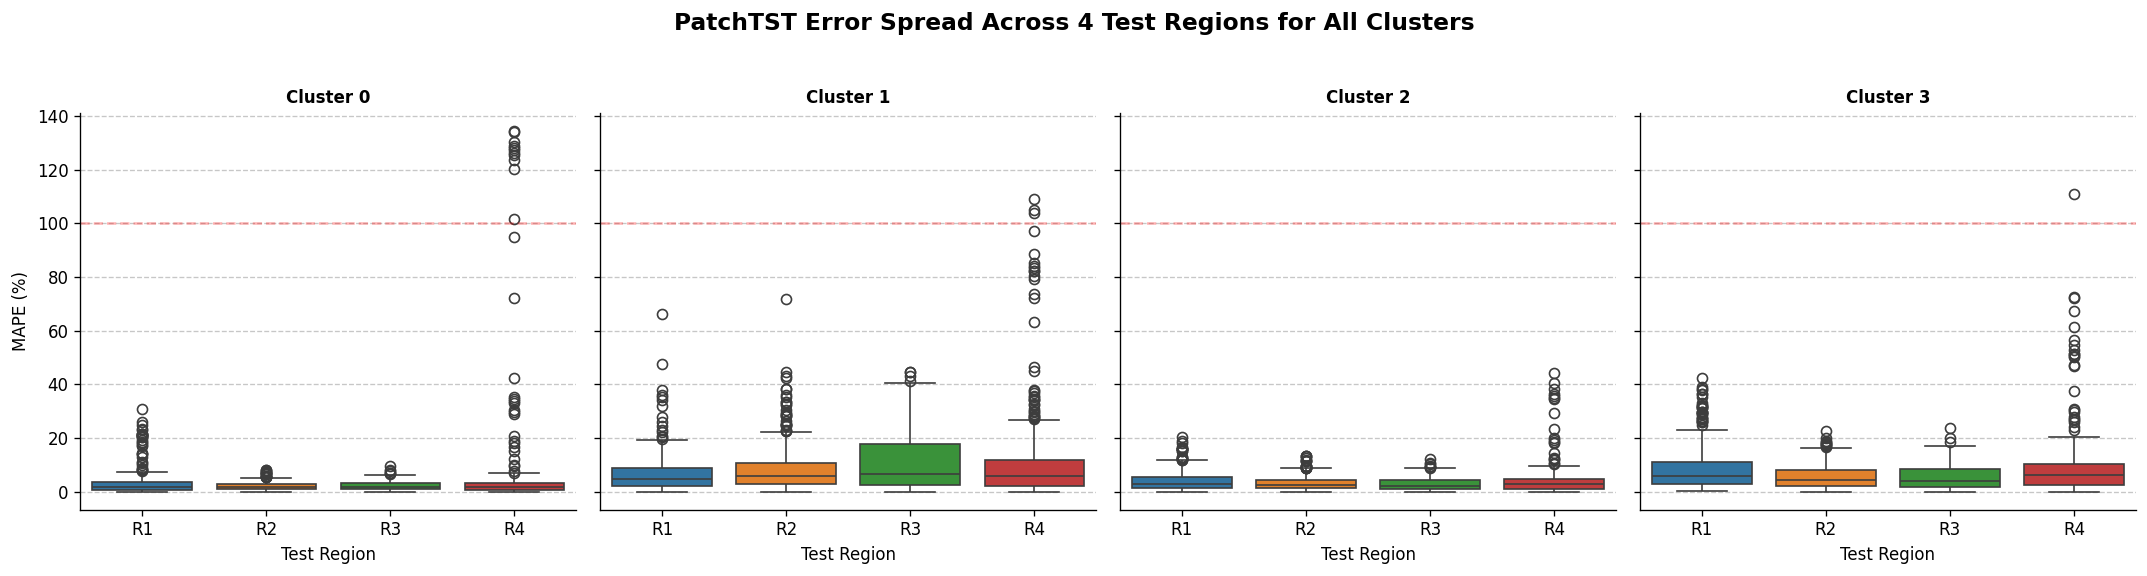

In [ ]:
def sliding_window_collect_apes(series_train, series_test, forecast_fn, horizon=24, n_windows=60, eps=0.1):
    """
    Performs a sliding window evaluation and collects all Absolute Percentage Errors (APEs).
    Returns a concatenated numpy array of all APE values.
    """
    test_len = len(series_test)
    # Ensure window_starts does not go out of bounds for test_series
    max_start = test_len - horizon
    if max_start < 0: # If test_len is smaller than horizon
        print("Warning: Test series is shorter than forecast horizon. Cannot generate APEs.")
        return np.array([])

    window_starts = np.linspace(0, max_start, n_windows, dtype=int)

    all_apes = []
    for start in window_starts:
        actual = series_test.iloc[start : start + horizon].values
        predicted = forecast_fn(series_train, series_test.iloc[:start], horizon)
        if predicted is not None and len(actual) == len(predicted):
            # Calculate Absolute Percentage Error (0-100 scale)
            ape = np.abs((actual - predicted) / np.maximum(np.abs(actual), eps)) * 100
            all_apes.append(ape.flatten())
        elif predicted is None:
            print(f"Warning: Forecast function returned None for window starting at index {start}. Skipping.")
        else:
            print(f"Warning: Mismatch in length between actual ({len(actual)}) and predicted ({len(predicted)}) for window starting at index {start}. Skipping.")

    if not all_apes:
        return np.array([])
    return np.concatenate(all_apes)

def get_patchtst_regional_errors(cluster_id, n_windows=60, num_regions=4):
    """
    Generates regional APEs for a given cluster using the PatchTST model.
    """
    tr_mean = train_series[cluster_id]
    te_mean = test_series[cluster_id]

    model = patchtst_models[cluster_id]
    train_mat = cluster_train_mat[cluster_id]
    test_mat = cluster_test_mat[cluster_id]
    train_index = df_hourly.loc[:TRAIN_END].index
    test_index = df_hourly.loc[TEST_START:TEST_END].index

    # Get the PatchTST forecast function for this cluster
    patchtst_fn = make_patchtst_forecast_fn(
        model=model,
        train_mat=train_mat,
        test_mat=test_mat,
        train_index=train_index,
        test_index=test_index,
        seq_len=SEQ_LEN,
    )

    # Collect all APE values using the custom sliding window function
    total_apes = sliding_window_collect_apes(tr_mean, te_mean, patchtst_fn, horizon=PRED_LEN, n_windows=n_windows)

    if len(total_apes) == 0:
        print("No APEs collected for analysis.")
        return []

    # Divide into equal regions
    region_size = len(total_apes) // num_regions
    regions = [total_apes[i * region_size : (i + 1) * region_size] for i in range(num_regions)]
    return regions

# --- Generate and Plot for PatchTST for all clusters ---

NUM_REGIONS = 4 # Number of regions to divide the errors into
N_WINDOWS_FOR_PLOT = 60 # Number of sliding windows to evaluate

fig, axes = plt.subplots(1, K, figsize=(18, 5), sharey=True)
if K == 1:
    axes = [axes] # Ensure axes is iterable even for a single cluster

for i, cluster_id in enumerate(sorted(cluster_members)):
    ax = axes[i]
    patchtst_regions = get_patchtst_regional_errors(cluster_id=cluster_id, n_windows=N_WINDOWS_FOR_PLOT, num_regions=NUM_REGIONS)

    if patchtst_regions:
        sns.boxplot(data=patchtst_regions, ax=ax)
        ax.set_title(f"Cluster {cluster_id}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Test Region")
        ax.set_xticks(range(NUM_REGIONS), [f'R{j+1}' for j in range(NUM_REGIONS)])
        ax.axhline(100, color='red', linestyle='--', alpha=0.3, label="100% Error Threshold")
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        if i == 0:
            ax.set_ylabel("MAPE (%)")
        else:
            ax.tick_params(labelleft=False) # Hide y-axis labels for other subplots
    else:
        ax.set_title(f"Cluster {cluster_id} (No data)", fontsize=10, fontweight="bold")
        ax.set_xlabel("Test Region")
        ax.tick_params(labelleft=False) # Hide y-axis labels

fig.suptitle(f"PatchTST Error Spread Across {NUM_REGIONS} Test Regions for All Clusters", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
import shutil
from google.colab import files
import os

MODEL_DIR = "/models"
OUTPUT_FILENAME = "models_archive"
ARCHIVE_FORMAT = "zip"

# Create a zip archive of the models directory
if os.path.exists(MODEL_DIR):
    archive_path = shutil.make_archive(OUTPUT_FILENAME, ARCHIVE_FORMAT, MODEL_DIR)
    print(f"Created archive: {archive_path}")
    # Download the created archive
    files.download(archive_path)
    print("Models archive queued for download.")
else:
    print(f"Error: The directory {MODEL_DIR} does not exist.")

Created archive: /content/models_archive.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Models archive queued for download.


#### reload model from checkpoint

In [ ]:
import torch

MODEL_DIR = "/models"
patchtst_models_loaded = {}

for c in range(K):
    ckpt_path = f"{MODEL_DIR}/cluster_{c}/patchtst.pt"
    ckpt = torch.load(ckpt_path, map_location=device) # Load checkpoint to the correct device
    cfg  = ckpt['config']

    model = PatchTST(
        seq_len   = cfg['seq_len'],
        pred_len  = cfg['pred_len'],
        patch_len = cfg['patch_len'],
        stride    = cfg['stride'],
        d_model   = cfg['d_model'],
        n_heads   = cfg['n_heads'],
        e_layers  = cfg['e_layers'],
        d_ff      = cfg['d_ff'],
        dropout   = cfg['dropout'],
    )
    model.load_state_dict(ckpt['state_dict'])
    model.to(device) # Ensure the model is on the correct device
    model.eval()
    patchtst_models_loaded[c] = (model, cfg)
    print(f"Cluster {c} loaded from {ckpt_path}")

Cluster 0 loaded from /models/cluster_0/patchtst.pt
Cluster 1 loaded from /models/cluster_1/patchtst.pt
Cluster 2 loaded from /models/cluster_2/patchtst.pt
Cluster 3 loaded from /models/cluster_3/patchtst.pt


In [ ]:
def make_patchtst_forecast_fn(
    model, train_mat, test_mat, train_index, test_index, seq_len=96
):
    """
    Returns a forecast_fn compatible with sliding_window_eval.

    sliding_window_eval passes the cluster-mean series (train, history, horizon).
    We use the last timestamp in `history` to look up the matching (seq_len, M)
    window in the individual-client matrix, run PatchTST, then average across
    M clients to produce the cluster-mean forecast.
    """
    full_mat   = np.vstack([train_mat, test_mat])   # (T_train + T_test, M)
    full_index = train_index.append(test_index)      # DatetimeIndex

    def forecast_fn(series_train_mean, history_mean, horizon=24):
        end_ts = (history_mean.index[-1]
                  if len(history_mean) > 0
                  else series_train_mean.index[-1])

        pos   = int(full_index.searchsorted(end_ts, side="right")) - 1
        start = pos - seq_len + 1
        if start < 0:
            return None

        # (seq_len, M) → (1, M, seq_len) tensor
        window = full_mat[start : pos + 1]
        x = torch.FloatTensor(window.T).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(x)                  # (1, M, pred_len)

        # Average M clients → cluster-mean forecast (pred_len,)
        return pred[0].mean(dim=0).cpu().numpy()

    return forecast_fn


# Shared time indices (same for all clusters)
train_idx = df_hourly.loc[:TRAIN_END].index
test_idx  = df_hourly.loc[TEST_START:TEST_END].index


In [ ]:
SEQ_LEN  = 168   # look-back: 168 h -  a week
PRED_LEN = 24   # horizon:   24 h (day-ahead, matching all other models)

cluster_members   = {}
cluster_train_mat = {}   # (T_train, M_c) per cluster
cluster_test_mat  = {}   # (T_test,  M_c) per cluster

for c in sorted(feature_matrix["cluster"].unique()):
    members = feature_matrix[feature_matrix["cluster"] == c].index.tolist()
    cluster_members[c]   = members
    cluster_train_mat[c] = df_hourly[members].loc[:TRAIN_END].values           # (T_train, M)
    cluster_test_mat[c]  = df_hourly[members].loc[TEST_START:TEST_END].values  # (T_test,  M)
    print(f"Cluster {c}: {len(members):3d} clients  "
          f"train={cluster_train_mat[c].shape}  test={cluster_test_mat[c].shape}")

Cluster 0: 215 clients  train=(17544, 215)  test=(8760, 215)
Cluster 1:  35 clients  train=(17544, 35)  test=(8760, 35)
Cluster 2:  91 clients  train=(17544, 91)  test=(8760, 91)
Cluster 3:  29 clients  train=(17544, 29)  test=(8760, 29)


In [ ]:
# ── 2. Evaluate with 365-window sliding_window_eval ──

patchtst_results = {}

for c in range(K):
    model, cfg = patchtst_models_loaded[c]

    fn = make_patchtst_forecast_fn(
        model       = model,
        train_mat   = cluster_train_mat[c],
        test_mat    = cluster_test_mat[c],
        train_index = train_idx,
        test_index  = test_idx,
        seq_len     = cfg['seq_len'],
    )

    res = sliding_window_eval(train_series[c], test_series[c], fn, n_windows=365)
    patchtst_results[c] = res
    print(f"Cluster {c} | MAPE={res['mape']:.2f}% sMAPE={res['smape']:.2f}%  MAE={res['mae']:.3f}  RMSE={res['rmse']:.3f}")

Cluster 0 | MAPE=4.49% sMAPE=2.50%  MAE=12.132  RMSE=15.141
Cluster 1 | MAPE=12.18% sMAPE=10.05%  MAE=142.691  RMSE=174.488
Cluster 2 | MAPE=13.60% sMAPE=3.35%  MAE=3.683  RMSE=4.616
Cluster 3 | MAPE=110.17% sMAPE=6.56%  MAE=67.718  RMSE=80.615


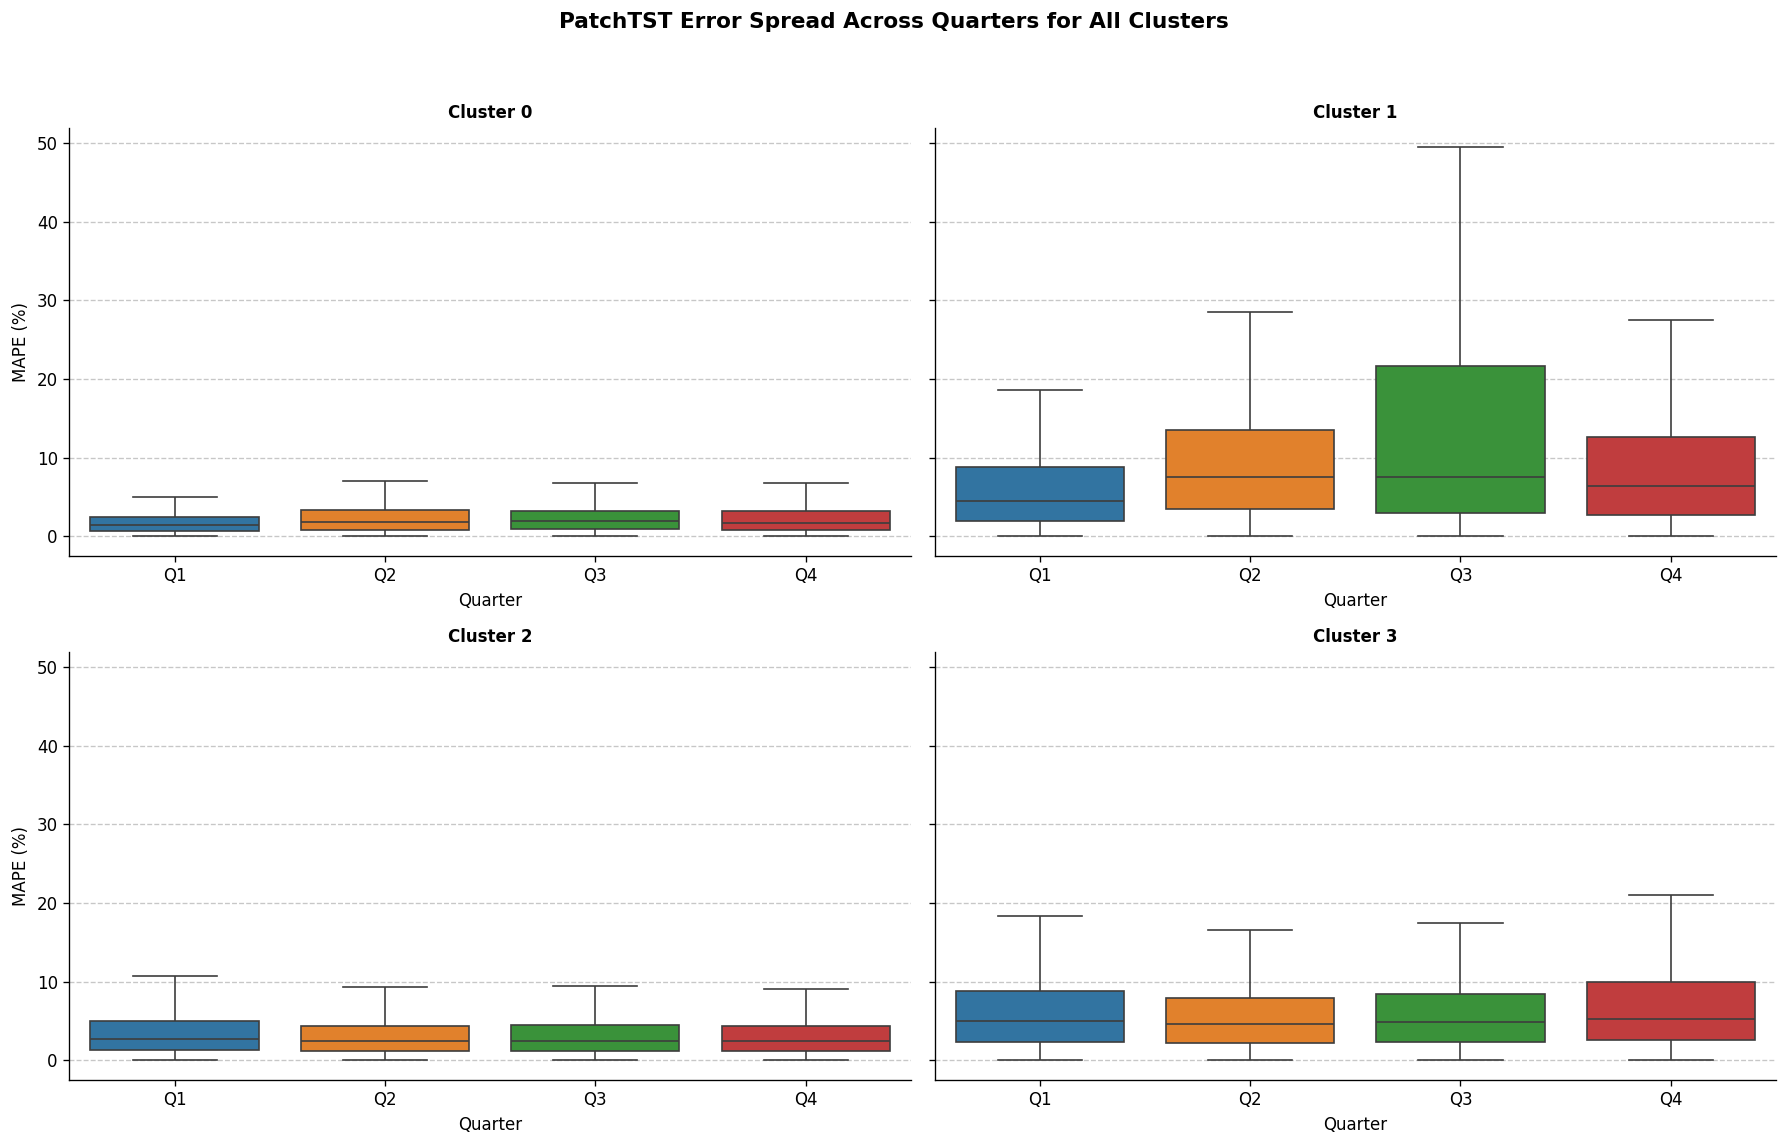

In [ ]:
# ── 3. MAPE box plots by quarter for all 4 clusters ──

def get_patchtst_regional_errors(cluster_id, n_windows=365):
    model, cfg = patchtst_models_loaded[cluster_id]
    fn = make_patchtst_forecast_fn(
        model       = model,
        train_mat   = cluster_train_mat[cluster_id],
        test_mat    = cluster_test_mat[cluster_id],
        train_index = train_series[cluster_id].index,
        test_index  = test_series[cluster_id].index,
        seq_len     = cfg['seq_len'],
    )
    tr = train_series[cluster_id]
    te = test_series[cluster_id]

    horizon = 24
    test_len = len(te)
    window_starts = np.linspace(0, test_len - horizon - 1, n_windows, dtype=int)

    quarters = {f'Q{q}': [] for q in range(1, 5)}
    for start in window_starts:
        actual    = te.iloc[start: start + horizon].values
        predicted = fn(tr, te.iloc[:start], horizon)
        ape = np.abs((actual - predicted) / np.maximum(np.abs(actual), 0.1)) * 100
        ts  = te.index[start]
        quarters[f'Q{ts.quarter}'].extend(ape.tolist())

    regions = []
    for q in ['Q1', 'Q2', 'Q3', 'Q4']:
        arr = np.array(quarters[q])
        regions.append(arr[arr <= 10000])
    return regions


fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axes = axes.flatten()

for i, c in enumerate(range(K)):
    ax = axes[i]
    regions = get_patchtst_regional_errors(cluster_id=c, n_windows=365)
    sns.boxplot(data=regions, ax=ax, showfliers=False)
    ax.set_title(f"Cluster {c}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Quarter")
    ax.set_xticks(range(4))
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if i % 2 == 0:
        ax.set_ylabel("MAPE (%)")

fig.suptitle("PatchTST Error Spread Across Quarters for All Clusters",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 5.7 BasisFormer

In [ ]:
# 1. Define the directory path
output_dir = '../all_six_datasets/electricity_clusters/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

# 2. Save each cluster series as a separate CSV
# cluster_series was defined in the previous block as a dict of pd.Series
for cluster_id, series in cluster_series.items():
    # Convert series to a DataFrame so it has a header '0' for the --target 0 flag
    df_cluster = series.to_frame(name='0')

    file_path = os.path.join(output_dir, f'cluster_{cluster_id}.csv')
    df_cluster.to_csv(file_path)
    print(f"Saved: {file_path} (Rows: {len(df_cluster)})")

Saved: ../all_six_datasets/electricity_clusters/cluster_0.csv (Rows: 26304)
Saved: ../all_six_datasets/electricity_clusters/cluster_1.csv (Rows: 26304)
Saved: ../all_six_datasets/electricity_clusters/cluster_2.csv (Rows: 26304)
Saved: ../all_six_datasets/electricity_clusters/cluster_3.csv (Rows: 26304)


In [ ]:
# Create a folder for clustered data to keep it separate from the 370-client run
os.makedirs('../all_six_datasets/electricity_clusters/', exist_ok=True)

for c in train_series.keys():
    # Combine train and test for the specific cluster
    full_cluster_df = pd.concat([train_series[c], test_series[c]])
    full_cluster_df.to_csv(f'../all_six_datasets/electricity_clusters/cluster_{c}.csv')

In [ ]:
output_dir = '../all_six_datasets/electricity_clusters/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for cluster_id, series in cluster_series.items():
    df_cluster = series.to_frame(name='0')

    # CRITICAL FIX: Name the index 'date' and move it to a column
    df_cluster.index.name = 'date'
    df_cluster = df_cluster.reset_index()

    file_path = os.path.join(output_dir, f'cluster_{cluster_id}.csv')
    df_cluster.to_csv(file_path, index=False) # index=False because 'date' is now a column
    print(f"Fixed & Saved: {file_path}")

Fixed & Saved: ../all_six_datasets/electricity_clusters/cluster_0.csv
Fixed & Saved: ../all_six_datasets/electricity_clusters/cluster_1.csv
Fixed & Saved: ../all_six_datasets/electricity_clusters/cluster_2.csv
Fixed & Saved: ../all_six_datasets/electricity_clusters/cluster_3.csv


In [ ]:
!python3 -u main.py \
  --is_training 1 \
  --root_path ../all_six_datasets/electricity_clusters/ \
  --data_path cluster_0.csv \
  --features S \
  --target 0 \
  --input_channel 1 \
  --train_epochs 10 \
  --patience 5 \
  --check_point checkpoint_cluster_0###

Args in experiment:
Namespace(is_training=True, device=0, num_workers=0, data='custom', root_path='../all_six_datasets/electricity_clusters/', data_path='cluster_0.csv', features='S', target='0', freq='h', seq_len=96, label_len=96, pred_len=96, input_channel=1, embed='timeF', heads=16, d_model=100, N=10, block_nums=2, bottleneck=2, map_bottleneck=20, train_epochs=10, batch_size=32, patience=5, learning_rate=0.0005, tau=0.07, loss_weight_prediction=1.0, loss_weight_infonce=1.0, loss_weight_smooth=1.0, check_point='checkpoint_cluster_0')
Basisformer(
  (coefnet): Coefnet(
    (layers): ModuleList(
      (0-1): 2 x BCAB(
        (cross_attention_basis): channel_AutoCorrelationLayer(
          (query_projection): Linear(in_features=100, out_features=96, bias=True)
          (key_projection): Linear(in_features=100, out_features=96, bias=True)
          (value_projection): Linear(in_features=100, out_features=96, bias=True)
          (out_projection): Linear(in_features=96, out_features=100

In [ ]:
# Cluster 1
!python3 -u main.py --is_training 1 --root_path ../all_six_datasets/electricity_clusters/ --data_path cluster_1.csv --features S --target 0 --input_channel 1 --train_epochs 10 --patience 5 --check_point checkpoint_cluster_1

# Cluster 2
!python3 -u main.py --is_training 1 --root_path ../all_six_datasets/electricity_clusters/ --data_path cluster_2.csv --features S --target 0 --input_channel 1 --train_epochs 10 --patience 5 --check_point checkpoint_cluster_2

# Cluster 3
!python3 -u main.py --is_training 1 --root_path ../all_six_datasets/electricity_clusters/ --data_path cluster_3.csv --features S --target 0 --input_channel 1 --train_epochs 10 --patience 5 --check_point checkpoint_cluster_3


Args in experiment:
Namespace(is_training=True, device=0, num_workers=0, data='custom', root_path='../all_six_datasets/electricity_clusters/', data_path='cluster_1.csv', features='S', target='0', freq='h', seq_len=96, label_len=96, pred_len=96, input_channel=1, embed='timeF', heads=16, d_model=100, N=10, block_nums=2, bottleneck=2, map_bottleneck=20, train_epochs=10, batch_size=32, patience=5, learning_rate=0.0005, tau=0.07, loss_weight_prediction=1.0, loss_weight_infonce=1.0, loss_weight_smooth=1.0, check_point='checkpoint_cluster_1')
Basisformer(
  (coefnet): Coefnet(
    (layers): ModuleList(
      (0-1): 2 x BCAB(
        (cross_attention_basis): channel_AutoCorrelationLayer(
          (query_projection): Linear(in_features=100, out_features=96, bias=True)
          (key_projection): Linear(in_features=100, out_features=96, bias=True)
          (value_projection): Linear(in_features=100, out_features=96, bias=True)
          (out_projection): Linear(in_features=96, out_features=100

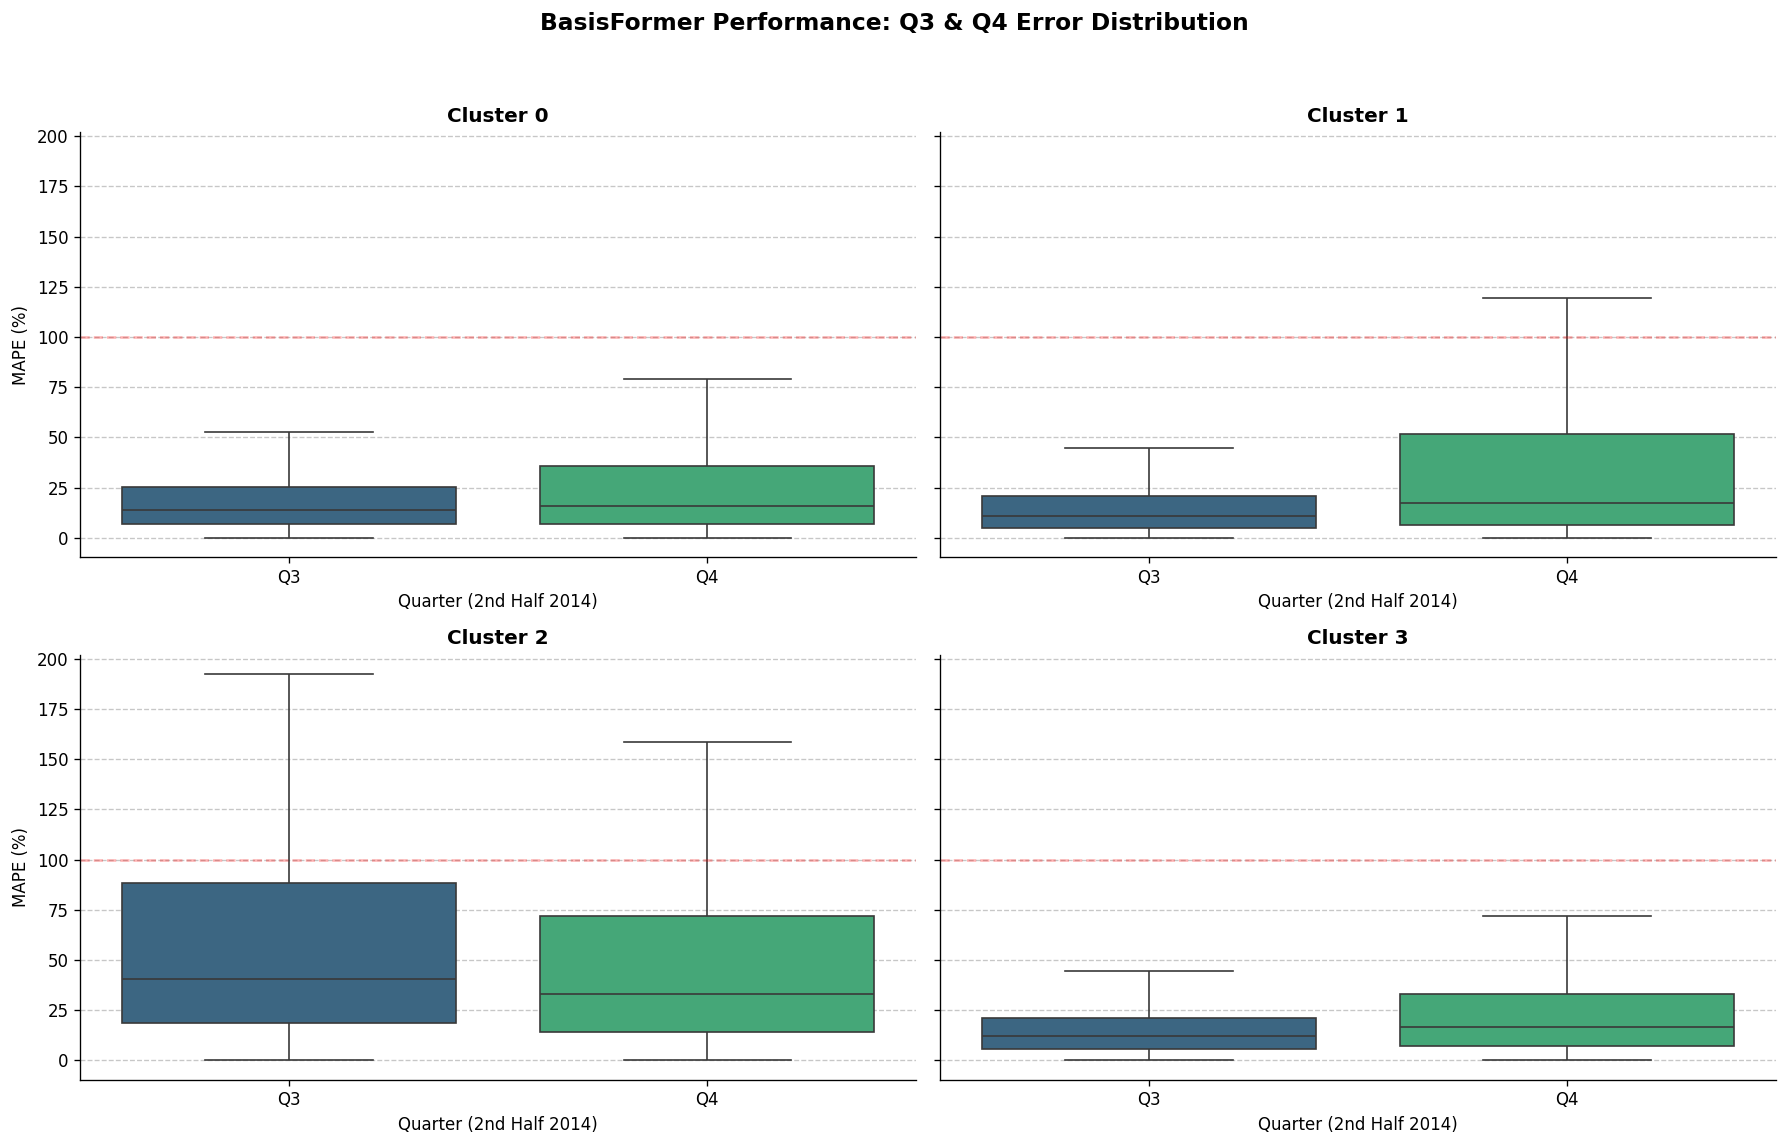

In [ ]:
# ── Updated Constants ──
BF_SEQ_LEN  = 96
BF_PRED_LEN = 24
BF_PATH     =  "../Project/Basisformer/records/cluster_{c}/features_S/seq_len{sl},pred_len{pl}"

def get_bf_regional_errors(cluster_id):
    path = BF_PATH.format(c=cluster_id, sl=BF_SEQ_LEN, pl=BF_PRED_LEN)

    # Load raw results
    preds = np.load(f"{path}/pred.npy")
    trues = np.load(f"{path}/true.npy")

    # Reshape to (n_windows, 24)
    if preds.ndim == 3:
        preds = preds[:, :, 0]
        trues = trues[:, :, 0]

    n_windows = len(preds)

    # ── Accurate Time Alignment ──
    # Since BasisFormer evaluates on the tail-end of the data (Q3/Q4),
    # we map the windows to the LAST n_windows of your test index.
    te_index = test_series[cluster_id].index
    window_timestamps = te_index[-n_windows:]

    # We only care about Q3 and Q4 per the updated requirement
    quarters = {'Q3': [], 'Q4': []}

    for i in range(n_windows):
        actual    = trues[i]
        predicted = preds[i]

        # ── Epsilon Removed ──
        # We now divide by raw 'actual' to match other model metrics.
        # Note: If actual is exactly 0.0, this will return 'inf'.
        ape = np.abs((actual - predicted) / actual) * 100

        ts = window_timestamps[i]
        q_label = f'Q{ts.quarter}'

        if q_label in quarters:
            quarters[q_label].extend(ape.tolist())

    # Filter out extreme outliers for visualization clarity (threshold 10000%)
    regions = []
    for q in ['Q3', 'Q4']:
        arr = np.array(quarters[q])
        regions.append(arr[arr <= 10000] if len(arr) > 0 else arr)

    return regions

# ── Plotting ──
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axes = axes.flatten()

for i, c in enumerate(range(4)): # K=4
    ax = axes[i]
    # Fetch Q3 and Q4 data
    regions = get_bf_regional_errors(cluster_id=c)

    # Only plotting Q3 and Q4
    labels = ['Q3', 'Q4']

    sns.boxplot(data=regions, ax=ax, showfliers=False, palette="viridis")

    ax.set_title(f"Cluster {c}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Quarter (2nd Half 2014)")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.axhline(100, color='red', linestyle='--', alpha=0.3)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    if i % 2 == 0:
        ax.set_ylabel("MAPE (%)")

fig.suptitle("BasisFormer Performance: Q3 & Q4 Error Distribution",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### BASISFORMER PERFORMANCE SUMMARY (2014 TEST SET) ###
  Cluster  Mean MAPE (%)  sMAPE (%)  MAE (kWh)  RMSE (kWh)
Cluster 0     171.990005  28.590000      0.161       0.232
Cluster 1     107.889999  31.320000      0.149       0.199
Cluster 2     136.440002  60.910000      0.222       0.284
Cluster 3     432.399994  22.940001      0.223       0.300


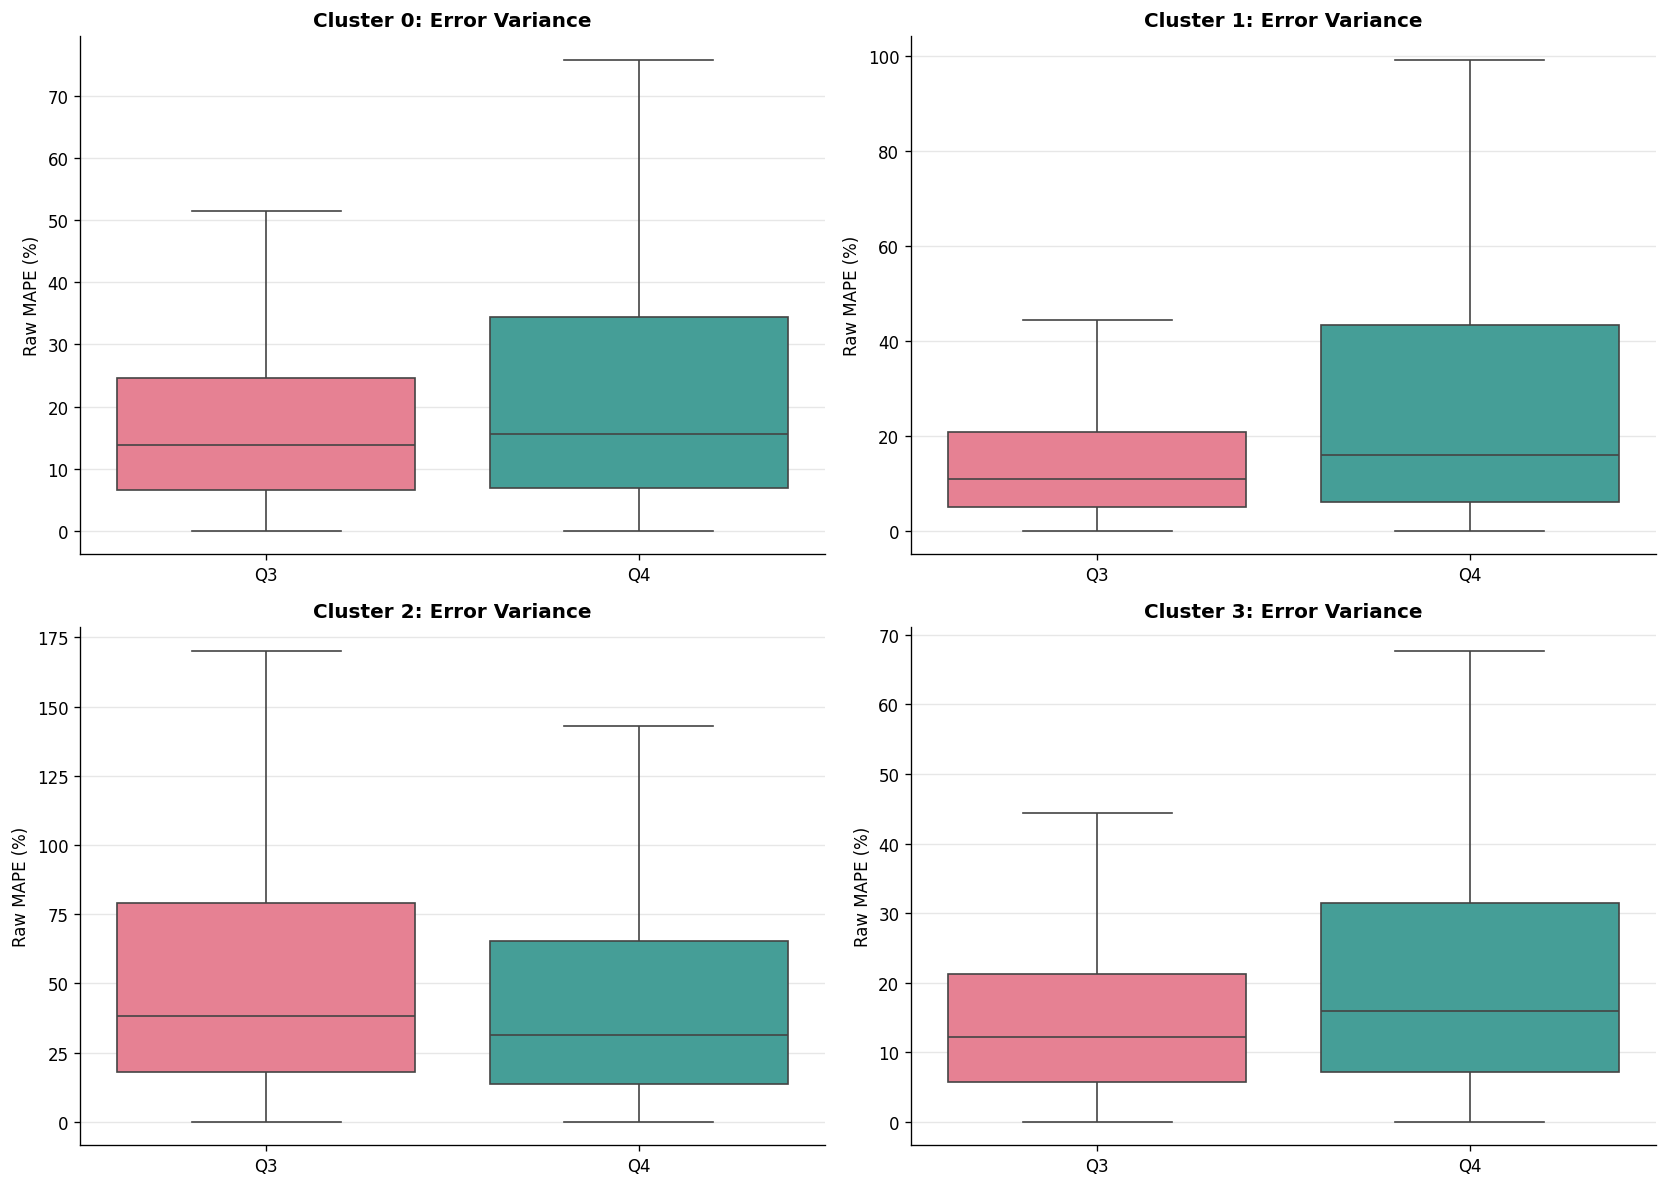

In [ ]:
BF_SEQ_LEN = 96
BF_PRED_LEN = 24
BASE_PATH = "../Project/Basisformer/records/cluster_{c}/features_S/seq_len{sl},pred_len{pl}"
def calculate_smape(actual, forecast):
    denominator = (np.abs(actual) + np.abs(forecast)) / 2
    # Using a tiny epsilon 1e-5 just to prevent computer crash, not a 0.1 'buffer'
    return np.mean(np.abs(forecast - actual) / np.maximum(denominator, 1e-5)) * 100

# --- 2. DATA EXTRACTION & METRIC CALCULATION ---
all_metrics = []
boxplot_data = {c: {'Q3': [], 'Q4': []} for c in range(4)}

for c in range(4):
    path = BASE_PATH.format(c=c, sl=BF_SEQ_LEN, pl=BF_PRED_LEN)
    preds = np.load(os.path.join(path, "pred.npy")).squeeze()
    trues = np.load(os.path.join(path, "true.npy")).squeeze()

    # Time Alignment: Match windows to the LAST part of the test index
    n_windows = len(preds)
    te_index = test_series[c].index
    window_timestamps = te_index[-n_windows:]

    # Calculate Global Metrics for the Table
    mae = np.mean(np.abs(trues - preds))
    rmse = np.sqrt(np.mean((trues - preds)**2))
    smape_val = calculate_smape(trues, preds)

    # Raw MAPE (No 0.1 buffer)
    # Using np.where to handle actual=0 without 'masking' the error with a buffer
    raw_ape = np.abs((trues - preds) / np.where(trues != 0, trues, np.nan)) * 100
    mean_mape = np.nanmean(raw_ape)

    all_metrics.append({
        "Cluster": f"Cluster {c}",
        "Mean MAPE (%)": round(mean_mape, 2),
        "sMAPE (%)": round(smape_val, 2),
        "MAE (kWh)": round(mae, 3),
        "RMSE (kWh)": round(rmse, 3)
    })

    # Grouping APE for Boxplots (Q3 & Q4 only)
    for i in range(n_windows):
        ts = window_timestamps[i]
        q_label = f'Q{ts.quarter}'
        if q_label in ['Q3', 'Q4']:
            # Flatten the 24-hour window of errors and add to list
            errs = raw_ape[i]
            boxplot_data[c][q_label].extend(errs[~np.isnan(errs)].tolist())

# --- 3. DISPLAY PERFORMANCE TABLE ---
df_performance = pd.DataFrame(all_metrics)
print("### BASISFORMER PERFORMANCE SUMMARY (2014 TEST SET) ###")
print(df_performance.to_string(index=False))

# --- 4. DISPLAY ERROR DISTRIBUTION (BOXPLOTS) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes = axes.flatten()

for c in range(4):
    ax = axes[c]
    q_data = [boxplot_data[c]['Q3'], boxplot_data[c]['Q4']]

    # Filtering for visualization (capping at 500% so the boxes are visible)
    filtered_data = [np.array(q)[np.array(q) <= 500] for q in q_data]

    sns.boxplot(data=filtered_data, ax=ax, showfliers=False, palette="husl")
    ax.set_title(f"Cluster {c}: Error Variance", fontweight="bold")
    ax.set_xticklabels(['Q3', 'Q4'])
    ax.set_ylabel("Raw MAPE (%)")
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()